In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from geopy.distance import geodesic
import os

def calculate_distance_from_point_to_station(row):
    station_coord = (row['LATITUDE:'], row['LONGITUDE:'])
    given_point_coord = (-15.760063, -47.871154)

    return geodesic(station_coord, given_point_coord).kilometers

df_all_stations = pd.read_csv("../data/all_stations.csv", decimal=",", sep=";")

df_all_stations["Distancia"] = df_all_stations.apply(calculate_distance_from_point_to_station, axis=1) 

df_nearest_stations = df_all_stations[(df_all_stations["Distancia"] < 35)] 

print(df_nearest_stations)

    REGI?O: UF:           ESTAC?O: CODIGO (WMO):     LATITUDE:    LONGITUDE:  \
141      CO  DF         BRAZLANDIA          A042  -15.59972221   -48.1311111   
233      CO  DF    AGUAS EMENDADAS          A045    -15.596491    -47.625801   
239      CO  DF  GAMA (PONTE ALTA)          A046  -15.93527777  -48.13749999   
442      CO  DF           BRASILIA          A001    -15.789343    -47.925756   

    ALTITUDE:                                            Arquivo  Distancia  
141    1143.0  INMET_CO_DF_A042_BRAZLANDIA_01-01-2019_A_31-12...  33.036886  
233   1030.36  INMET_CO_DF_A045_AGUAS EMENDADAS_01-01-2019_A_...  31.928860  
239     990.0  INMET_CO_DF_A046_GAMA (PONTE ALTA)_01-01-2019_...  34.494431  
442   1160.96  INMET_CO_DF_A001_BRASILIA_01-01-2019_A_31-12-2...   6.688014  


In [2]:
yeardirectoryfilename = []
df_nearest_stations_weather_data = []

for filename in df_nearest_stations['Arquivo']: 
    yeardirectoryfilename.append(filename)

    df_weather_data = pd.read_csv(f'../data/cleaned_data/2019_cleaned/{filename}', decimal=".", sep=";")
    df_weather_data.rename(columns={'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO GLOBAL (KJ/m²)'}, inplace=True)
    df_nearest_stations_weather_data.append(df_weather_data)

    df_weather_data = pd.read_csv(f'../data/cleaned_data/2020_cleaned/{filename.replace("2019", "2020")}', decimal=".", sep=";")
    df_weather_data.rename(columns={'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO GLOBAL (KJ/m²)'}, inplace=True)
    df_nearest_stations_weather_data.append(df_weather_data)

    df_weather_data = pd.read_csv(f'../data/cleaned_data/2021_cleaned/{filename.replace("2019", "2021")}', decimal=".", sep=";")
    df_weather_data.rename(columns={'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO GLOBAL (KJ/m²)'}, inplace=True)
    df_nearest_stations_weather_data.append(df_weather_data)

    df_weather_data = pd.read_csv(f'../data/cleaned_data/2022_cleaned/{filename.replace("2019", "2022")}', decimal=".", sep=";")
    df_weather_data.rename(columns={'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO GLOBAL (KJ/m²)'}, inplace=True)
    df_nearest_stations_weather_data.append(df_weather_data)

    df_weather_data = pd.read_csv(f'../data/cleaned_data/2023_cleaned/{filename.replace("2019", "2023")}', decimal=".", sep=";")
    df_weather_data.rename(columns={'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO GLOBAL (KJ/m²)'}, inplace=True)
    df_nearest_stations_weather_data.append(df_weather_data)

    df_weather_data = pd.read_csv(f'../data/cleaned_data/2024_cleaned/{filename.replace("2019", "2024")}', decimal=".", sep=";")
    df_weather_data.rename(columns={'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO GLOBAL (KJ/m²)'}, inplace=True)
    df_nearest_stations_weather_data.append(df_weather_data)

df_compilation_of_nearest_stations_weather_data = pd.concat(df_nearest_stations_weather_data, ignore_index= True)


df_compilation_of_nearest_stations_weather_data

,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (KJ/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)"
0,2019/01/01,0000 UTC,0.0,888.4,888.4,887.7,NaN,18.7,17.4,19.4,18.6,17.4,17.1,92.0,87.0,92.0,329.0,5.3,1.2
1,2019/01/01,0100 UTC,0.2,889.0,889.0,888.4,NaN,19.0,17.5,19.0,18.5,17.5,17.3,93.0,91.0,91.0,67.0,3.3,2.0
2,2019/01/01,0200 UTC,0.2,889.2,889.2,889.0,NaN,18.9,17.4,19.0,18.8,17.5,17.4,92.0,91.0,91.0,37.0,3.3,1.4
3,2019/01/01,0300 UTC,0.0,888.6,889.2,888.6,NaN,18.6,16.8,19.0,18.6,17.4,16.7,91.0,87.0,89.0,24.0,2.6,0.9
4,2019/01/01,0400 UTC,0.0,887.9,888.6,887.9,NaN,18.6,17.2,18.7,18.4,17.3,16.8,93.0,89.0,91.0,21.0,2.4,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210427,2024/12/31,1900 UTC,0.0,884.5,885.0,884.5,2061.5,26.3,18.2,26.7,25.4,18.9,16.6,65.0,56.0,61.0,351.0,6.3,3.3
210428,2024/12/31,2000 UTC,0.0,884.1,884.5,884.0,1940.0,26.2,17.7,26.7,25.8,18.4,17.2,62.0,58.0,59.0,348.0,7.4,3.7
210429,2024/12/31,2100 UTC,0.0,884.3,884.4,884.1,877.0,21.7,18.9,26.3,21.6,19.0,17.3,84.0,59.0,84.0,3.0,12.1,3.4
210430,2024/12/31,2200 UTC,0.0,884.5,884.5,884.1,109.8,21.3,19.4,21.8,21.2,19.4,18.8,89.0,84.0,89.0,356.0,5.3,2.5


<class 'pandas.core.frame.DataFrame'>
Index: 210432 entries, 0 to 210431
Data columns (total 18 columns):
 #   Column                                                 Non-Null Count   Dtype         
---  ------                                                 --------------   -----         
 0   Data                                                   210432 non-null  datetime64[ns]
 1   PRECIPITAÇÃO TOTAL, HORÁRIO (mm)                       206648 non-null  float64       
 2   PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)  207298 non-null  float64       
 3   PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)        207246 non-null  float64       
 4   PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)       207244 non-null  float64       
 5   RADIACAO GLOBAL (KJ/m²)                                111276 non-null  float64       
 6   TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)           207331 non-null  float64       
 7   TEMPERATURA DO PONTO DE ORVALHO (°C)                   207322

Text(0.5, 1.0, 'Precipitação Média Diária - Universidade de Brasília (-15.760063, -47.871154)')

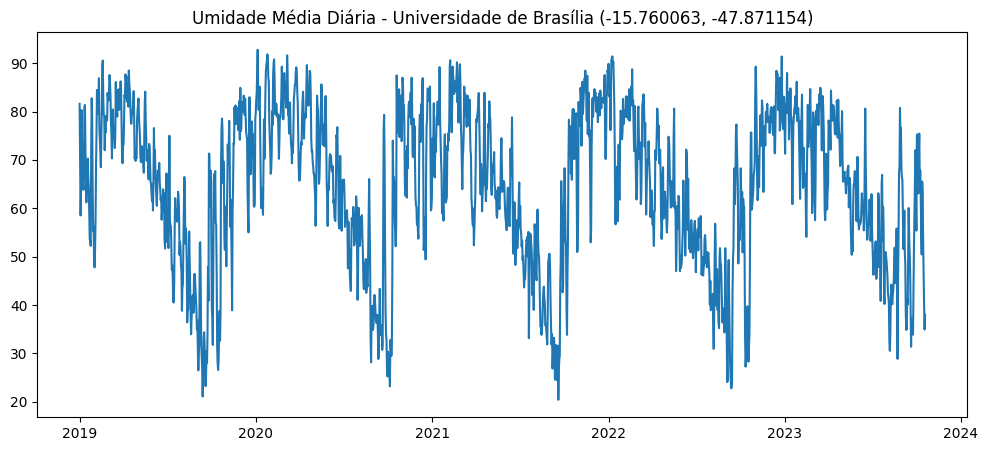

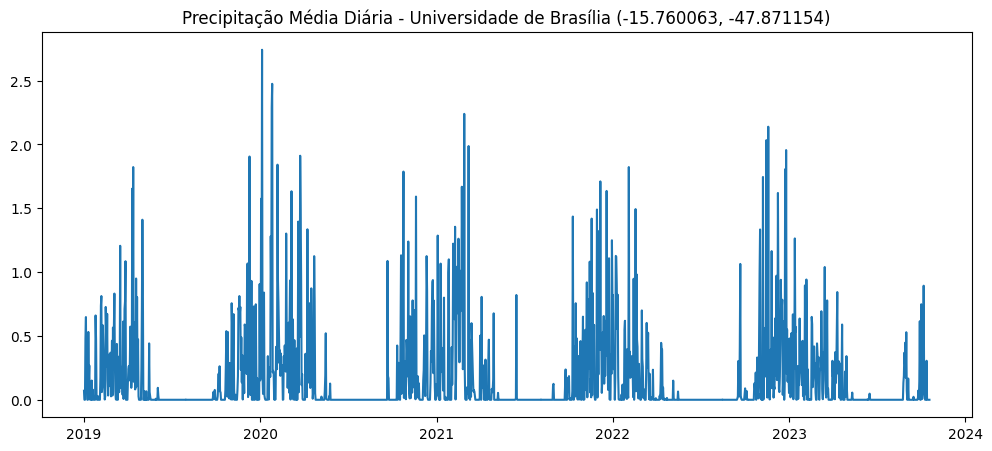

In [3]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error


df_cleaned = df_compilation_of_nearest_stations_weather_data.drop(columns=['Hora UTC'])

df_cleaned['Data'] = pd.to_datetime(df_cleaned['Data'])

df_sorted = df_cleaned.sort_values(by='Data', ascending=True)

df_sorted.info()

forecast_parameter = 'UMIDADE RELATIVA DO AR, HORARIA (%)'

#Converte Data
df_sorted.set_index('Data', inplace=True)
df_avarage_humidity_by_day = df_sorted.resample("D").mean()

print(df_avarage_humidity_by_day)

# Verificar se há valores nulos
print(df_avarage_humidity_by_day.isnull().sum())

# Tratar valores nulos
df_not_null_values_day = df_avarage_humidity_by_day.ffill()

# Divisão dos dados em treinamento (80%) e teste (20%)- DAILY
df_splited_data = int(len(df_not_null_values_day) * 0.8)
df_training, df_test = df_not_null_values_day[:df_splited_data], df_not_null_values_day[df_splited_data:]  

print(df_training)

#Teste
plt.figure(figsize=(12, 5))
plt.plot(df_training[forecast_parameter], label='Forecast')
plt.title('Average Daily Humidity - University of Brasilia (-15.760063, -47.871154)')


#Teste
plt.figure(figsize=(12, 5))
plt.plot(df_training['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], label='Forecast')
plt.title('Average Daily Precipitation - University of Brasilia (-15.760063, -47.871154)')


In [4]:
# Define o threshold de umidade usando apenas os dados de treino

# 1. Limite onde SEMPRE CHOVE
# Equivalente à umidade máxima observada em dias com precipitação == 0
dias_sem_chuva = df_training[df_training['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] == 0]

if not dias_sem_chuva.empty:
    threshold_umidade = dias_sem_chuva[forecast_parameter].max()
    print(f"Threshold de umidade calculado (acima disto SEMPRE chove): {threshold_umidade:.2f}%")
    print(f"Para dias no treino com umidade superior a {threshold_umidade:.2f}%, sempre houve precipitação (> 0).")
    
    # Verificação
    dias_acima_threshold = df_training[df_training[forecast_parameter] > threshold_umidade]
    if not dias_acima_threshold.empty:
        precip_minima = dias_acima_threshold['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].min()
        print(f"Precipitação mínima nesses dias: {precip_minima} mm\n")
    else:
        print("Não há dias com umidade acima do threshold no conjunto de treino.\n")
else:
    print("Não há dias sem chuva no conjunto de treino para calcular o threshold.\n")

# 2. Limite onde NUNCA CHOVE
# Equivalente à umidade mínima observada em dias com precipitação > 0
dias_com_chuva = df_training[df_training['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] > 0]

if not dias_com_chuva.empty:
    threshold_nunca_chove = dias_com_chuva[forecast_parameter].min()
    print(f"Threshold de umidade calculado (abaixo disto NUNCA chove): {threshold_nunca_chove:.2f}%")
    print(f"Para dias no treino com umidade inferior a {threshold_nunca_chove:.2f}%, a precipitação foi sempre 0.")
    
    # Verificação 
    dias_abaixo_threshold = df_training[df_training[forecast_parameter] < threshold_nunca_chove]
    if not dias_abaixo_threshold.empty:
        precip_maxima = dias_abaixo_threshold['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].max()
        print(f"Precipitação máxima nesses dias: {precip_maxima} mm")
    else:
        print("Não há dias com umidade abaixo do threshold no conjunto de treino.")
else:
    print("Não há dias com chuva no conjunto de treino para calcular o threshold.")

Threshold de umidade calculado (acima disto SEMPRE chove): 82.25%
Para dias no treino com umidade superior a 82.25%, sempre houve precipitação (> 0).
Precipitação mínima nesses dias: 0.004166666666666667 mm

Threshold de umidade calculado (abaixo disto NUNCA chove): 39.83%
Para dias no treino com umidade inferior a 39.83%, a precipitação foi sempre 0.
Precipitação máxima nesses dias: 0.0 mm


--- Otimização Estatística de Threshold ---
O Threshold Ótimo encontrado foi: 67.68% de Umidade
O F1-Score máximo obtido foi: 0.8630


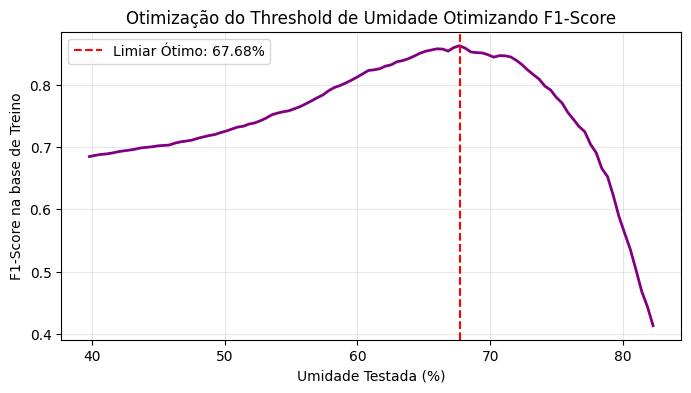

In [5]:
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

print("--- Otimização Estatística de Threshold ---")

# Define a verdade de "choveu ou não" (1 para chuva, 0 para seca seca)
y_true_precipitacao = (df_training['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] > 0).astype(int)

# Vamos testar valores de umidade desde o limite em que 'nunca chove' até o 'sempre chove'
possiveis_limiares = np.linspace(threshold_nunca_chove, threshold_umidade, 100)
f1_scores = []

for limiar in possiveis_limiares:
    # Se a umidade for maior que o limiar de teste, prevemos chuva (1)
    y_pred_teste = (df_training[forecast_parameter] > limiar).astype(int)
    
    # Calcular o F1 (zero_division impede erros de divisão por zero caso preveja tudo como 0)
    score = f1_score(y_true_precipitacao, y_pred_teste, zero_division=0)
    f1_scores.append(score)

# Achar o máximo F1 Score e o Umidade ótima associada
indice_otimo = np.argmax(f1_scores)
threshold_f1_otimizado = possiveis_limiares[indice_otimo]
melhor_f1 = f1_scores[indice_otimo]

print(f"O Threshold Ótimo encontrado foi: {threshold_f1_otimizado:.2f}% de Umidade")
print(f"O F1-Score máximo obtido foi: {melhor_f1:.4f}")

# Plot da Curva de Otimização F1
plt.figure(figsize=(8, 4))
plt.plot(possiveis_limiares, f1_scores, color='purple', linewidth=2)
plt.axvline(x=threshold_f1_otimizado, color='red', linestyle='--', label=f'Optimal Threshold: {threshold_f1_otimizado:.2f}%')
plt.title('Humidity Threshold Optimization Maximizing F1-Score')
plt.xlabel('Tested Humidity (%)')
plt.ylabel('F1-Score on Training Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Exportamos explicitamente o resultado para o notebook usar futuramente
threshold_otimizado = threshold_f1_otimizado

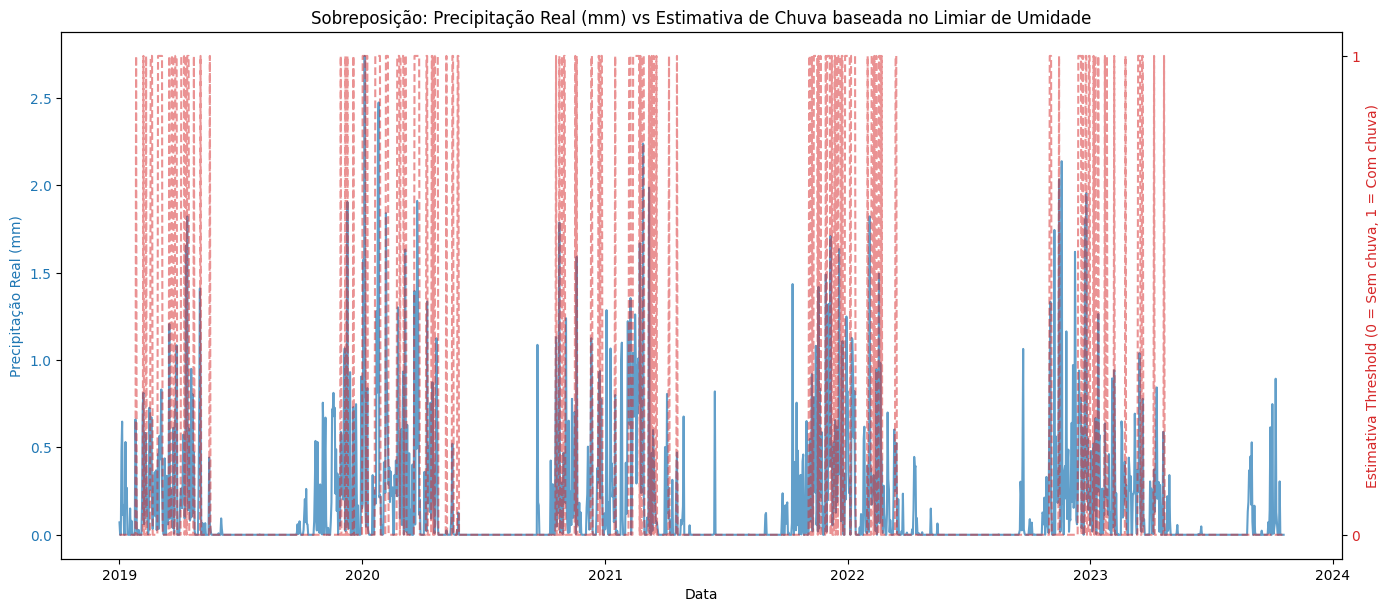

In [6]:
# Cria uma série (0 para não choveu e 1 para choveu) baseada no threshold da umidade
df_training_estimada = (df_training[forecast_parameter] > threshold_umidade).astype(int)

# Plota os gráficos sobrepostos para comparação visual
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eixo y para a Precipitação (em azul)
color1 = 'tab:blue'
ax1.set_xlabel('Data')
ax1.set_ylabel('Precipitação Real (mm)', color=color1)
ax1.plot(df_training.index, df_training['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], color=color1, alpha=0.7, label='Precipitação Real')
ax1.tick_params(axis='y', labelcolor=color1)

# Eixo y secundário para a Estimativa (em vermelho)
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('Estimativa Threshold (0 = Sem chuva, 1 = Com chuva)', color=color2)
ax2.plot(df_training.index, df_training_estimada, color=color2, linestyle='--', alpha=0.5, label='Estimativa de Chuva')
ax2.set_yticks([0, 1])
ax2.tick_params(axis='y', labelcolor=color2)

fig.tight_layout()
plt.title('Overlay: Observed Precipitation (mm) vs Rain Estimate Based on Humidity Threshold')
plt.show()

RMSE bruto: 11.036 | debias (ME): 11.138 | calib linear: 11.092
MSE: 124.04483001635487
RMSE: 11.137541470915153
sMAPE: 14.302655055974775


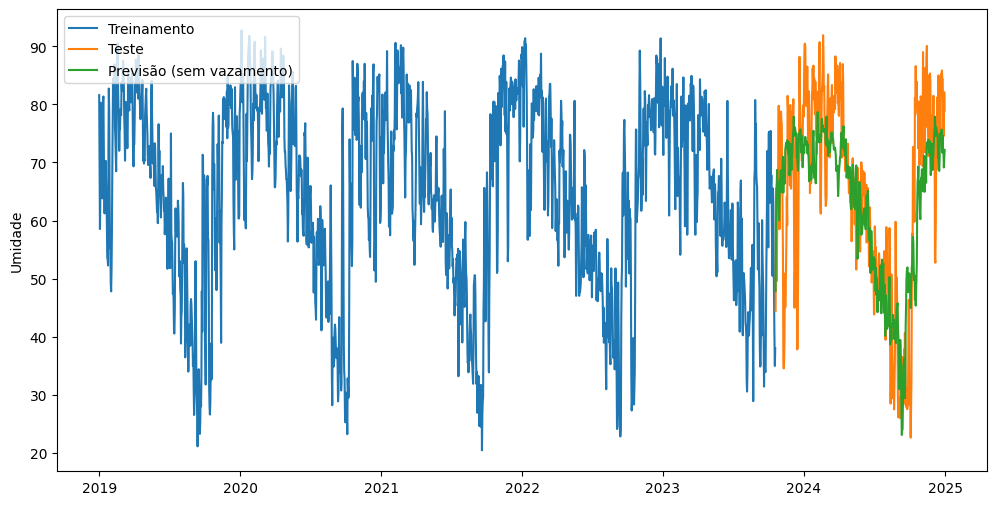

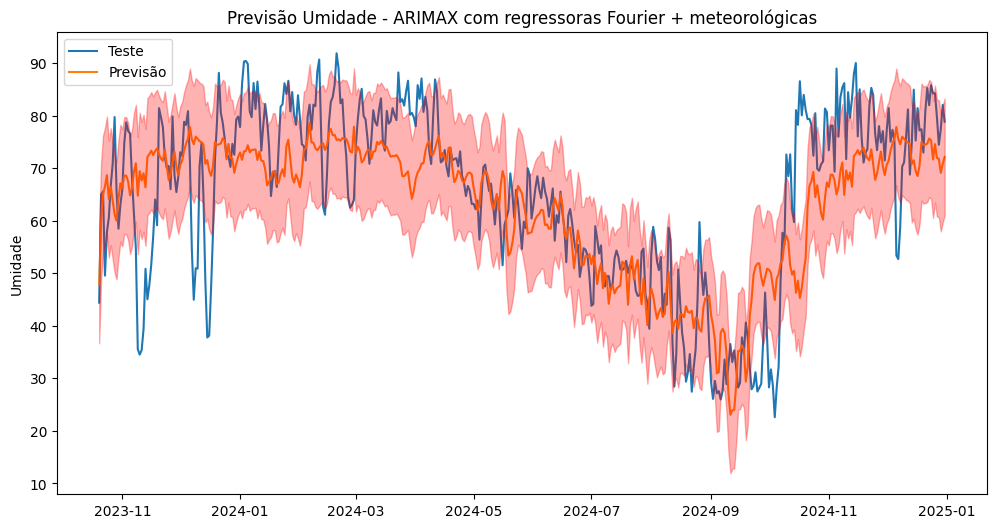

In [7]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import seaborn as sns
import statsmodels.api as sm

from pmdarima import auto_arima

def clean_data(dataframe):
    df_cleaned = dataframe.drop(columns=['Hora UTC'])
    df_cleaned['Data'] = pd.to_datetime(df_cleaned['Data'])

    df_sorted = df_cleaned.sort_values(by='Data', ascending=True)
    df_sorted.set_index('Data', inplace=True)
    df_avarage_humidity_by_day = df_sorted.resample("D").mean()
    df_not_null_values_day = df_avarage_humidity_by_day.ffill()

    return df_not_null_values_day

def create_fourier_terms(t, period, num_terms):
    terms = []
    for i in range(1, num_terms + 1):
        terms.append(np.sin(2 * np.pi * i * t / period))
        terms.append(np.cos(2 * np.pi * i * t / period))
    return np.column_stack(terms)

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))


def get_forecast_test_graph(df_test, forecast, forecast_parameter, ax):
    import numpy as np
    from scipy import stats
    from sklearn.metrics import mean_squared_error
    import seaborn as sns

    values = np.vstack([df_test[forecast_parameter], forecast])
    kernel = stats.gaussian_kde(values)(values)

    sns.scatterplot(
        x=df_test[forecast_parameter],
        y=forecast,
        hue=kernel,
        palette="viridis",
        ax=ax,
        legend=False
    )

    mse = mean_squared_error(df_test[forecast_parameter], forecast)
    rmse = mse**0.5

    ax.plot(df_test[forecast_parameter], df_test[forecast_parameter], color='black', linewidth=1.0)

    ax.text(0.95, 0.05, f'RMSE: {rmse:.2f} °C', ha='right', va='bottom', transform=ax.transAxes, fontsize=10)

    ax.set_ylabel('Observed Humidity (%)')
    ax.set_xlabel('Forecast Humidity (%)')

def arima_forecast_with_fourier_terms_exog(df_training, df_test, forecast_parameter, title, lag_days=365):
    n = len(df_training[forecast_parameter])
    t = np.arange(n)
    seasonality = 365
    num_fourier_terms = 4

    exog_vars = [
        "TEMPERATURA DO PONTO DE ORVALHO (°C)",
        "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)"
    ]

    # Termos de fourier e variáveis exógenas do treino
    fourier_terms_train = create_fourier_terms(t, seasonality, num_fourier_terms)
    X_train_extra = df_training[exog_vars].values
    X_train_final = np.hstack([X_train_extra, fourier_terms_train[:n]])

     # Construção das variáveis exógenas do teste
    # perfil por (mês, dia): média de todos os anos do treino
    prof = df_training.copy()
    prof["__mm__"] = prof.index.month
    prof["__dd__"] = prof.index.day
    profile_mmdd = (
        prof.groupby(["__mm__", "__dd__"])[exog_vars]
        .mean() 
    )

    # índice (mês, dia) do teste 
    test_mm = pd.Index(df_test.index.month, name="__mm__")
    test_dd = pd.Index(df_test.index.day, name="__dd__")
    test_mmdd = pd.MultiIndex.from_arrays([test_mm, test_dd], names=["__mm__", "__dd__"])

    # mapeia (mês, dia) do teste -> média climatológica do treino
    X_test_extra_df = profile_mmdd.reindex(test_mmdd)

    # tratamento de datas 
    # fallback 1: média de (28/02) e (01/03)
    missing_rows = X_test_extra_df.isna().any(axis=1)
    if missing_rows.any():
        feb28 = profile_mmdd.reindex(pd.MultiIndex.from_arrays(
            [pd.Index([2], name="__mm__"), pd.Index([28], name="__dd__")]
        ))
        mar01 = profile_mmdd.reindex(pd.MultiIndex.from_arrays(
            [pd.Index([3], name="__mm__"), pd.Index([1], name="__dd__")]
        ))
        neigh_avg = (feb28.values + mar01.values) / 2.0 if (not feb28.isna().any().any() and not mar01.isna().any().any()) else None
        if neigh_avg is not None:
            X_test_extra_df.loc[missing_rows, exog_vars] = neigh_avg

    # fallback 2: perfil por dia-do-ano (módulo 365) do treino
    if X_test_extra_df.isna().any().any():
        prof_doy = df_training.copy()
        prof_doy["__doy__"] = prof_doy.index.dayofyear
        profile_doy = prof_doy.groupby("__doy__")[exog_vars].mean()
        test_doy = ((df_test.index.dayofyear - 1) % 365) + 1
        X_fallback_doy = profile_doy.reindex(test_doy).to_numpy()
        X_test_extra_df = X_test_extra_df.fillna(pd.DataFrame(
            X_fallback_doy, index=X_test_extra_df.index, columns=exog_vars
        ))

    # fallback 3: qualquer NaN remanescente -> média da coluna 
    if X_test_extra_df.isna().any().any():
        for col in exog_vars:
            X_test_extra_df[col].fillna(X_test_extra_df[col].mean(), inplace=True)

    X_test_extra = X_test_extra_df.to_numpy() 

    # fourier para o horizonte (com mesmo length do df_test) 
    forecast_steps = len(df_test)
    fourier_terms_test = create_fourier_terms(
        np.arange(n, n + forecast_steps),
        seasonality,
        num_fourier_terms
    )
    X_test_final = np.hstack([X_test_extra, fourier_terms_test])

    # Previsão 
    model = ARIMA(
        df_training[forecast_parameter],
        exog=X_train_final,
        order=(2,1,3),
        trend='n'
    )
    model_fit = model.fit()

    forecast_vals = model_fit.forecast(steps=forecast_steps, exog=X_test_final)

    cal = debias_with_calibration(model_fit, df_training, forecast_parameter, X_train_final, forecast_vals, calib_days=60)
    rmse_raw = mean_squared_error(df_test[forecast_parameter], forecast_vals)**0.5
    rmse_bias = mean_squared_error(df_test[forecast_parameter], cal["forecast_bias_fixed"])**0.5
    rmse_lin  = mean_squared_error(df_test[forecast_parameter], cal["forecast_linear_cal"])**0.5

    print(f"RMSE bruto: {rmse_raw:.3f} | debias (ME): {rmse_bias:.3f} | calib linear: {rmse_lin:.3f}")

    forecast_corrected = cal["forecast_bias_fixed"]

    # Plot dos resultados
    plt.figure(figsize=(12, 6))
    plt.plot(df_training.index, df_training[forecast_parameter], label='Training')
    plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
    plt.plot(df_test.index, forecast_corrected, label='Forecast (no leakage)')
    plt.ylabel('Humidity')
    plt.legend(loc='upper left')

    # Cálculo métricas de erro

    mse = mean_squared_error(df_test[forecast_parameter], forecast_corrected)
    rmse = mse ** 0.5
    smape_value = smape(df_test[forecast_parameter], forecast_corrected)
    print(f'MSE: {mse}')
    print(f'RMSE: {rmse}')
    print(f'sMAPE: {smape_value}')

    plt.figure(figsize=(12,6))
    plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
    plt.plot(df_test.index, forecast_corrected, label='Forecast')
    plt.ylabel('Humidity')
    plt.legend(loc='upper left')
    plt.title(f"Humidity Forecast - ARIMAX with Fourier + meteorological regressors")
    plt.legend()
    plt.fill_between(df_test.index, (forecast_corrected-rmse), (forecast_corrected+rmse), alpha=.3, color='r', zorder=20)


    return pd.Series(forecast_corrected, index=df_test.index, name='forecast')


def debias_with_calibration(model_fit, df_training, forecast_parameter, X_train_final, forecast_vals, calib_days=60):
    # previsões 1-passo à frente na cauda do TREINO (janela de calibração)
    start = len(df_training) - calib_days
    pred_cal = model_fit.get_prediction(
        start=df_training.index[start],
        end=df_training.index[-1],
        exog=X_train_final[start:]
    ).predicted_mean
    y_cal = df_training[forecast_parameter].iloc[start:]

    # medir viés (ME) e corrigir por deslocamento 
    ME = (y_cal - pred_cal).mean()
    forecast_bias_fixed = forecast_vals + ME

    # correção linear (intercepto + inclinação)
    X = sm.add_constant(pred_cal.values)
    a, b = sm.OLS(y_cal.values, X).fit().params
    forecast_linear_cal = a + b * forecast_vals

    return {
        "ME": ME,
        "forecast_bias_fixed": forecast_bias_fixed,
        "a": a, "b": b,
        "forecast_linear_cal": forecast_linear_cal
    }

forecast = arima_forecast_with_fourier_terms_exog(df_training, df_test, 'UMIDADE RELATIVA DO AR, HORARIA (%)', f'Humidity Forecast - ARIMAX with Fourier + meteorological regressors')


/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE bruto: 0.347 | debias (ME): 0.348 | calib linear: 0.347
23 pontos de teste com umidade abaixo ou igual ao threshold de 39.83%, que terão precipitação prevista zerada.
MSE: 0.12052111094285763
RMSE: 0.34716150556024733
sMAPE: 135.90800022373153
Porcentagem de pontos dentro do intervalo (Previsto ± RMSE): 81.55%


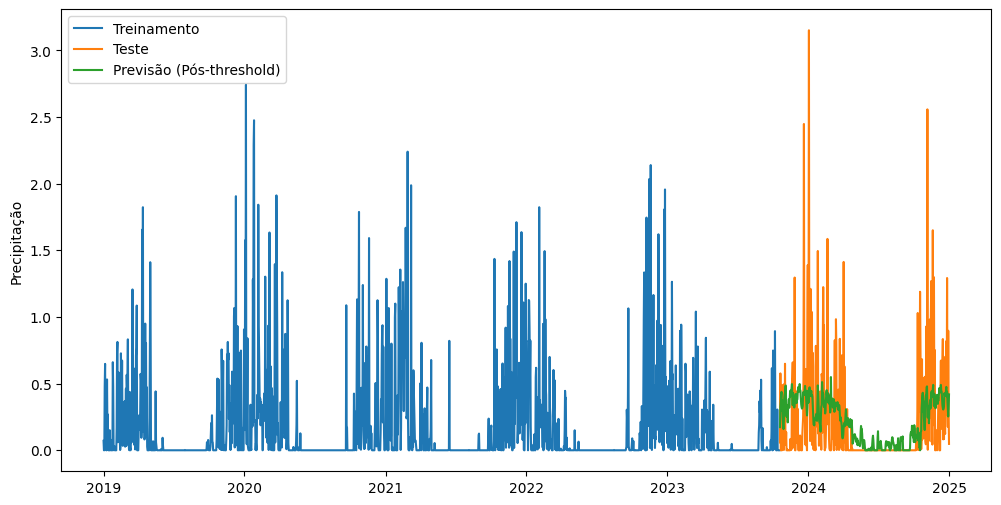

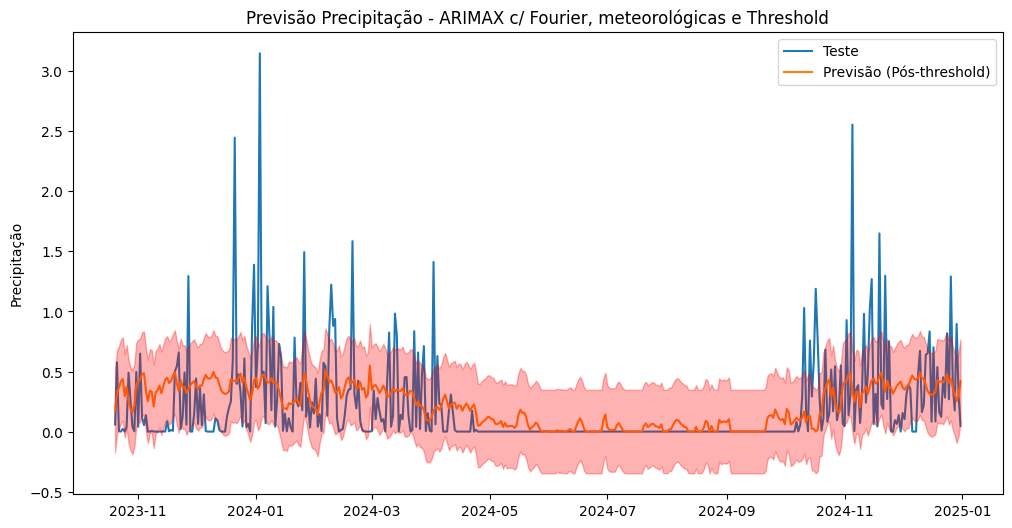

In [8]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import seaborn as sns
import statsmodels.api as sm
import numpy as np

from pmdarima import auto_arima


def clean_data(dataframe):
    df_cleaned = dataframe.drop(columns=['Hora UTC'])
    df_cleaned['Data'] = pd.to_datetime(df_cleaned['Data'])

    df_sorted = df_cleaned.sort_values(by='Data', ascending=True)
    df_sorted.set_index('Data', inplace=True)
    df_avarage_precipitation_by_day = df_sorted.resample("D").mean()
    df_not_null_values_day = df_avarage_precipitation_by_day.ffill()

    return df_not_null_values_day

def create_fourier_terms(t, period, num_terms):
    terms = []
    for i in range(1, num_terms + 1):
        terms.append(np.sin(2 * np.pi * i * t / period))
        terms.append(np.cos(2 * np.pi * i * t / period))
    return np.column_stack(terms)

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))


def get_forecast_test_graph(df_test, forecast_series, forecast_parameter, ax):
    import numpy as np
    from scipy import stats
    from sklearn.metrics import mean_squared_error
    import seaborn as sns

    values = np.vstack([df_test[forecast_parameter], forecast_series])
    kernel = stats.gaussian_kde(values)(values)

    sns.scatterplot(
        x=df_test[forecast_parameter],
        y=forecast_series,
        hue=kernel,
        palette="viridis",
        ax=ax,
        legend=False
    )

    mse = mean_squared_error(df_test[forecast_parameter], forecast_series)
    rmse = mse**0.5

    ax.plot(df_test[forecast_parameter], df_test[forecast_parameter], color='black', linewidth=1.0)

    ax.text(0.95, 0.05, f'RMSE: {rmse:.2f} °C', ha='right', va='bottom', transform=ax.transAxes, fontsize=10)

    ax.set_ylabel('Observed Precipitation (mm)')
    ax.set_xlabel('Forecast Precipitation (mm)')

def arima_forecast_with_fourier_terms_exog(df_training, df_test, forecast_parameter, title, lag_days=365, umidade_prevista=None, threshold_nunca_chove=82):
    n = len(df_training[forecast_parameter])
    t = np.arange(n)
    seasonality = 365
    num_fourier_terms = 4

    exog_vars = [
        "VENTO, DIREÇÃO HORARIA (gr) (° (gr))",
        "TEMPERATURA DO PONTO DE ORVALHO (°C)",
        "UMIDADE RELATIVA DO AR, HORARIA (%)"
    ]

    # Exogenas do treino
    fourier_terms_train = create_fourier_terms(t, seasonality, num_fourier_terms)
    X_train_extra = df_training[exog_vars].values
    X_train_final = np.hstack([X_train_extra, fourier_terms_train[:n]])

    # Exogenas do teste
    prof = df_training.copy()
    prof["__mm__"] = prof.index.month
    prof["__dd__"] = prof.index.day
    profile_mmdd = (
        prof.groupby(["__mm__", "__dd__"])[exog_vars]
        .mean()  
    )

    test_mm = pd.Index(df_test.index.month, name="__mm__")
    test_dd = pd.Index(df_test.index.day, name="__dd__")
    test_mmdd = pd.MultiIndex.from_arrays([test_mm, test_dd], names=["__mm__", "__dd__"])

    X_test_extra_df = profile_mmdd.reindex(test_mmdd)
    # fallback 1: média dos vizinhos (28/02 e 01/03) do perfil mensal-dia do TREINO
    missing_rows = X_test_extra_df.isna().any(axis=1)
    if missing_rows.any():
        feb28 = profile_mmdd.reindex(pd.MultiIndex.from_arrays(
            [pd.Index([2], name="__mm__"), pd.Index([28], name="__dd__")]
        ))
        mar01 = profile_mmdd.reindex(pd.MultiIndex.from_arrays(
            [pd.Index([3], name="__mm__"), pd.Index([1], name="__dd__")]
        ))
        neigh_avg = (feb28.values + mar01.values) / 2.0 if (not feb28.isna().any().any() and not mar01.isna().any().any()) else None
        if neigh_avg is not None:
            X_test_extra_df.loc[missing_rows, exog_vars] = neigh_avg

    # fallback 2: perfil por dia-do-ano (módulo 365) do TREINO
    if X_test_extra_df.isna().any().any():
        prof_doy = df_training.copy()
        prof_doy["__doy__"] = prof_doy.index.dayofyear
        profile_doy = prof_doy.groupby("__doy__")[exog_vars].mean()
        test_doy = ((df_test.index.dayofyear - 1) % 365) + 1
        X_fallback_doy = profile_doy.reindex(test_doy).to_numpy()
        X_test_extra_df = X_test_extra_df.fillna(pd.DataFrame(
            X_fallback_doy, index=X_test_extra_df.index, columns=exog_vars
        ))

    # fallback 3: qualquer NaN remanescente -> média da coluna (não usa futuro)
    if X_test_extra_df.isna().any().any():
        for col in exog_vars:
            X_test_extra_df[col].fillna(X_test_extra_df[col].mean(), inplace=True)
            
    # Se a previsão de umidade for passada, substitui a umidade das variáveis exógenas
    # if umidade_prevista is not None:
    #     X_test_extra_df['UMIDADE RELATIVA DO AR, HORARIA (%)'] = umidade_prevista.values

    X_test_extra = X_test_extra_df.to_numpy()  # shape = (len(df_test), len(exog_vars))

    # fourier para o horizonte (com mesmo length do df_test) 
    forecast_steps = len(df_test)
    fourier_terms_test = create_fourier_terms(
        np.arange(n, n + forecast_steps),
        seasonality,
        num_fourier_terms
    )
    X_test_final = np.hstack([X_test_extra, fourier_terms_test])

    # Previsão 
    model = ARIMA(
        df_training[forecast_parameter],
        exog=X_train_final,
        order=(3,0,1),
        trend='ct'
    )
    model_fit = model.fit()

    forecast_vals = model_fit.forecast(steps=forecast_steps, exog=X_test_final)

    cal = debias_with_calibration(model_fit, df_training, forecast_parameter, X_train_final, forecast_vals, calib_days=60)
    rmse_raw = mean_squared_error(df_test[forecast_parameter], forecast_vals)**0.5
    rmse_bias = mean_squared_error(df_test[forecast_parameter], cal["forecast_bias_fixed"])**0.5
    rmse_lin  = mean_squared_error(df_test[forecast_parameter], cal["forecast_linear_cal"])**0.5

    print(f"RMSE bruto: {rmse_raw:.3f} | debias (ME): {rmse_bias:.3f} | calib linear: {rmse_lin:.3f}")

    forecast_corrected = cal["forecast_bias_fixed"]

    # --- APLICAÇÃO DO THRESHOLD DE UMIDADE ---
    # Para evitar vazamento de dados, usa a umidade PREVISTA (repassada por parâmetro)
    umidade_teste = umidade_prevista if umidade_prevista is not None else df_test['UMIDADE RELATIVA DO AR, HORARIA (%)']
    
    print((umidade_teste <= threshold_nunca_chove).sum(), f"pontos de teste com umidade abaixo ou igual ao threshold de {threshold_nunca_chove:.2f}%, que terão precipitação prevista zerada.")

    # Zera a precipitação prevista quando a umidade for menor ou igual ao threshold
    forecast_corrected.loc[umidade_teste <= threshold_nunca_chove] = 0
    
    # Garante que não haja precipitações negativas
    forecast_corrected.loc[forecast_corrected < 0] = 0
    # -----------------------------------------

    # Plot dos resultados
    plt.figure(figsize=(12, 6))
    plt.plot(df_training.index, df_training[forecast_parameter], label='Training')
    plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
    plt.plot(df_test.index, forecast_corrected, label='Forecast (post-threshold)')
    plt.ylabel('Precipitation')
    plt.legend(loc='upper left')

  
    # Cálculo métricas de erro
    mse = mean_squared_error(df_test[forecast_parameter], forecast_corrected)
    rmse = mse ** 0.5
    smape_value = smape(df_test[forecast_parameter], forecast_corrected)
    print(f'MSE: {mse}')
    print(f'RMSE: {rmse}')
    print(f'sMAPE: {smape_value}')

    # Porcentagem de pontos dentro do intervalo Previsto +- RMSE
    lower_bound = forecast_corrected - rmse
    upper_bound = forecast_corrected + rmse
    actual_values = df_test[forecast_parameter]

    within_range = ((actual_values >= lower_bound) & (actual_values <= upper_bound)).mean() * 100
    print(f"Porcentagem de pontos dentro do intervalo (Previsto ± RMSE): {within_range:.2f}%")

    plt.figure(figsize=(12,6))
    plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
    plt.plot(df_test.index, forecast_corrected, label='Forecast (post-threshold)')
    plt.ylabel('Precipitation')
    plt.legend(loc='upper left')
    plt.title(f"Precipitation Forecast - ARIMAX with Fourier, meteorological regressors and threshold")
    plt.legend()
    plt.fill_between(df_test.index, (forecast_corrected-rmse), (forecast_corrected+rmse), alpha=.3, color='r', zorder=20)


    return pd.Series(forecast_corrected, index=df_test.index, name='forecast')


def debias_with_calibration(model_fit, df_training, forecast_parameter, X_train_final, forecast_vals, calib_days=60):
    # previsões 1-passo à frente na cauda do TREINO (janela de calibração)
    start = len(df_training) - calib_days
    pred_cal = model_fit.get_prediction(
        start=df_training.index[start],
        end=df_training.index[-1],
        exog=X_train_final[start:]
    ).predicted_mean
    y_cal = df_training[forecast_parameter].iloc[start:]

    # medir viés (ME) e corrigir por deslocamento 
    ME = (y_cal - pred_cal).mean()
    forecast_bias_fixed = forecast_vals + ME

    # correção linear (intercepto + inclinação)
    X = sm.add_constant(pred_cal.values)
    a, b = sm.OLS(y_cal.values, X).fit().params
    forecast_linear_cal = a + b * forecast_vals

    return {
        "ME": ME,
        "forecast_bias_fixed": forecast_bias_fixed,
        "a": a, "b": b,
        "forecast_linear_cal": forecast_linear_cal
    }

# A variável 'forecast' no escopo global contém a previsão de umidade gerada na célula anterior
forecast_precipitacao = arima_forecast_with_fourier_terms_exog(
    df_training, 
    df_test, 
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)', 
    'Precipitation Forecast - ARIMAX with Fourier + meteorological regressors', 
    umidade_prevista=forecast,
    threshold_nunca_chove=threshold_nunca_chove
)

Adicionando o vetor binário no ARIMA usando o threshold estatístico otimizado: 67.68%


/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


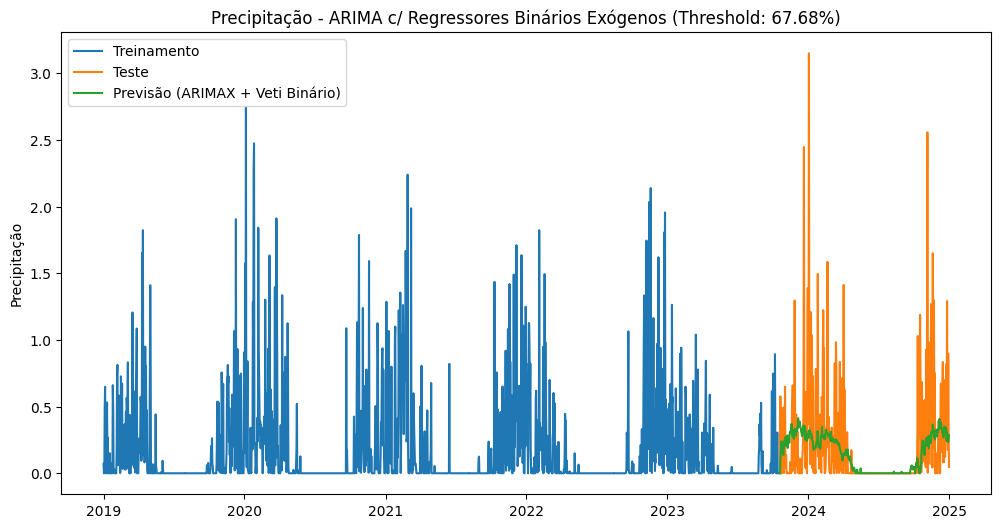

Métricas com Exógena Binária -> MSE: 0.1212 | RMSE: 0.3481 | sMAPE: 121.7673
Porcentagem de pontos dentro do intervalo (Previsto ± RMSE): 87.02%


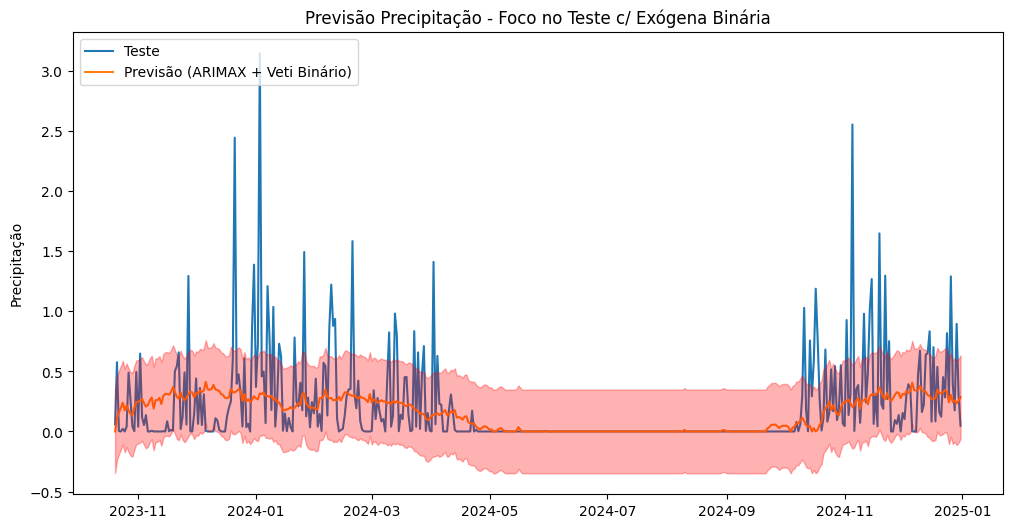

In [9]:
# ==============================================================================
# Tentativa 2: Usar o Vetor Binário (0 ou 1) como VARIÁVEL EXÓGENA no ARIMA
# Utilizando o threshold_otimizado (minimiza o erro F1)
# ==============================================================================

def arima_forecast_with_binary_exog(df_training, df_test, forecast_parameter, umidade_prevista, threshold_corte):
    n = len(df_training[forecast_parameter])
    t = np.arange(n)
    seasonality = 365
    num_fourier_terms = 4

    exog_vars = [
        "VENTO, DIREÇÃO HORARIA (gr) (° (gr))",
        "TEMPERATURA DO PONTO DE ORVALHO (°C)",
        "UMIDADE RELATIVA DO AR, HORARIA (%)"
    ]

    # --- 1. PREPARAÇÃO DAS EXÓGENAS DO TREINO ---
    fourier_terms_train = create_fourier_terms(t, seasonality, num_fourier_terms)
    
    X_train_extra_df = df_training[exog_vars].copy()
    
    # CRIA VARIÁVEL EXÓGENA BINÁRIA NO TREINAMENTO: 1 se umidade > threshold, 0 caso contrário
    X_train_extra_df['EXOG_BINARIA_CHUVA'] = (X_train_extra_df['UMIDADE RELATIVA DO AR, HORARIA (%)'] > threshold_corte).astype(int)
    
    X_train_extra = X_train_extra_df.values
    X_train_final = np.hstack([X_train_extra, fourier_terms_train[:n]])

    # --- 2. PREPARAÇÃO DAS EXÓGENAS DO TESTE ---
    # Criação do perfil climatológico (idêntico ao anterior para vento e ponto de orvalho)
    prof = df_training.copy()
    prof["__mm__"] = prof.index.month
    prof["__dd__"] = prof.index.day
    profile_mmdd = prof.groupby(["__mm__", "__dd__"])[exog_vars].mean()  

    test_mm = pd.Index(df_test.index.month, name="__mm__")
    test_dd = pd.Index(df_test.index.day, name="__dd__")
    test_mmdd = pd.MultiIndex.from_arrays([test_mm, test_dd], names=["__mm__", "__dd__"])

    X_test_extra_df = profile_mmdd.reindex(test_mmdd)
    
    # Preenchimento de NaNs no fallback climatológico...
    for col in exog_vars:
        if X_test_extra_df[col].isna().any():
            X_test_extra_df[col] = X_test_extra_df[col].fillna(X_test_extra_df[col].mean())
            
    # Substitui a umidade climatológica pela nossa UMIDADE PREVISTA real
    X_test_extra_df['UMIDADE RELATIVA DO AR, HORARIA (%)'] = umidade_prevista.values
    
    # CRIA VARIÁVEL EXÓGENA BINÁRIA NO TESTE: 1 se UMIDADE PREVISTA > threshold, 0 caso contrário
    X_test_extra_df['EXOG_BINARIA_CHUVA'] = (X_test_extra_df['UMIDADE RELATIVA DO AR, HORARIA (%)'] > threshold_corte).astype(int)

    X_test_extra = X_test_extra_df.to_numpy()

    # fourier para o horizonte de teste
    forecast_steps = len(df_test)
    fourier_terms_test = create_fourier_terms(np.arange(n, n + forecast_steps), seasonality, num_fourier_terms)
    
    X_test_final = np.hstack([X_test_extra, fourier_terms_test])

    # --- 3. TREINAMENTO E PREVISÃO DO MODELO ---
    model = ARIMA(
        df_training[forecast_parameter],
        exog=X_train_final,
        order=(3,0,1),
        trend='ct'
    )
    model_fit = model.fit()

    forecast_vals = model_fit.forecast(steps=forecast_steps, exog=X_test_final)

    cal = debias_with_calibration(model_fit, df_training, forecast_parameter, X_train_final, forecast_vals, calib_days=60)
    forecast_corrected = cal["forecast_bias_fixed"]

    # Garante que não haja precipitações negativas
    forecast_corrected.loc[forecast_corrected < 0] = 0

    # --- 4. PLOTS E MÉTRICAS ---
    plt.figure(figsize=(12, 6))
    plt.plot(df_training.index, df_training[forecast_parameter], label='Training')
    plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
    plt.plot(df_test.index, forecast_corrected, label='Forecast (ARIMAX + Binary Vector)')
    plt.ylabel('Precipitation')
    plt.title(f"Precipitation - ARIMA with Binary Exogenous Regressors (Threshold: {threshold_corte:.2f}%)")
    plt.legend(loc='upper left')
    plt.show()
  
    mse = mean_squared_error(df_test[forecast_parameter], forecast_corrected)
    rmse = mse ** 0.5
    smape_value = smape(df_test[forecast_parameter], forecast_corrected)
    print(f'Métricas com Exógena Binária -> MSE: {mse:.4f} | RMSE: {rmse:.4f} | sMAPE: {smape_value:.4f}')

    # Plot aproximado + RMSE
    lower_bound = forecast_corrected - rmse
    upper_bound = forecast_corrected + rmse
    actual_values = df_test[forecast_parameter]

    within_range = ((actual_values >= lower_bound) & (actual_values <= upper_bound)).mean() * 100
    print(f"Porcentagem de pontos dentro do intervalo (Previsto ± RMSE): {within_range:.2f}%")

    plt.figure(figsize=(12,6))
    plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
    plt.plot(df_test.index, forecast_corrected, label='Forecast (ARIMAX + Binary Vector)')
    plt.ylabel('Precipitation')
    plt.legend(loc='upper left')
    plt.title(f"Precipitation Forecast - Test Focus with Binary Exogenous Variable")
    plt.fill_between(df_test.index, (forecast_corrected-rmse), (forecast_corrected+rmse), alpha=.3, color='r', zorder=20)
    plt.show()

    return pd.Series(forecast_corrected, index=df_test.index, name='forecast')

# Executando a nova abordagem de previsão
# Usa-se o threshold_otimizado calculado usando as técnicas de F1 score
print(f"Adicionando o vetor binário no ARIMA usando o threshold estatístico otimizado: {threshold_otimizado:.2f}%")

forecast_precipitacao_exog_binaria = arima_forecast_with_binary_exog(
    df_training, 
    df_test, 
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)', 
    umidade_prevista=forecast,
    threshold_corte=threshold_otimizado # Limite otimizado!
)

Executando modelo utilizando o threshold otimizado do F1-score: 67.68%


/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


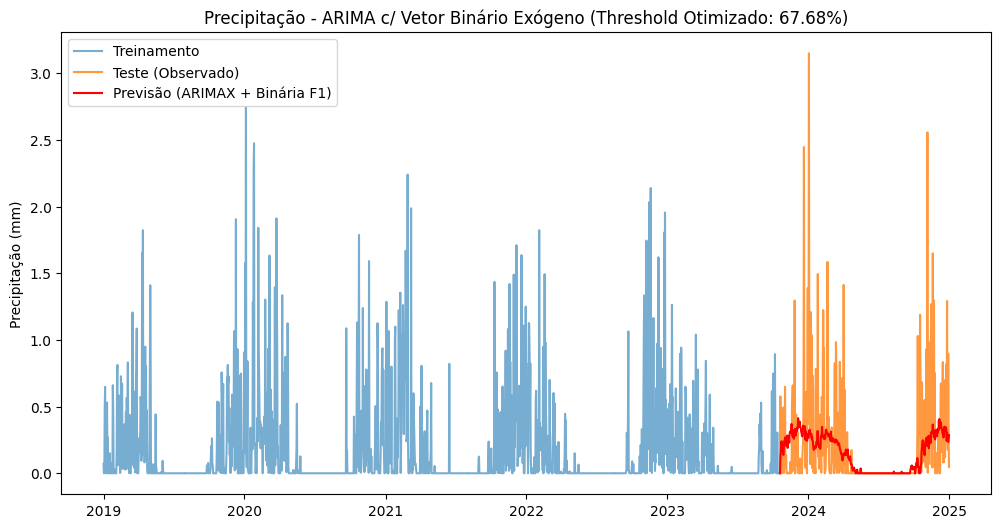


--- MÉTRICAS DE ERRO (ARIMAX + VETOR BINÁRIO) ---
MSE:   0.1212
RMSE:  0.3481
sMAPE: 121.7673
Pontos dentro do intervalo (Previsto ± RMSE): 87.02%


In [10]:
# ==============================================================================
# Evolução: ARIMA com Vetor Binário (0 ou 1) como Variável Exógena
# Utilizando o threshold_otimizado derivado do F1 Score
# ==============================================================================
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import numpy as np
import pandas as pd

def arima_forecast_with_f1_binary_exog(df_training, df_test, forecast_parameter, umidade_prevista, threshold_corte):
    n = len(df_training[forecast_parameter])
    t = np.arange(n)
    seasonality = 365
    num_fourier_terms = 4

    exog_vars = [
        "VENTO, DIREÇÃO HORARIA (gr) (° (gr))",
        "TEMPERATURA DO PONTO DE ORVALHO (°C)",
        "UMIDADE RELATIVA DO AR, HORARIA (%)"
    ]

    # --- 1. PREPARAÇÃO DAS EXÓGENAS DO TREINO ---
    fourier_terms_train = create_fourier_terms(t, seasonality, num_fourier_terms)
    
    X_train_extra_df = df_training[exog_vars].copy()
    
    # CRIA VARIÁVEL EXÓGENA BINÁRIA NO TREINAMENTO (1 se umidade > threshold, 0 caso contrário)
    X_train_extra_df['EXOG_BINARIA_CHUVA'] = (X_train_extra_df['UMIDADE RELATIVA DO AR, HORARIA (%)'] > threshold_corte).astype(int)
    
    X_train_extra = X_train_extra_df.values
    X_train_final = np.hstack([X_train_extra, fourier_terms_train[:n]])

    # --- 2. PREPARAÇÃO DAS EXÓGENAS DO TESTE ---
    prof = df_training.copy()
    prof["__mm__"] = prof.index.month
    prof["__dd__"] = prof.index.day
    profile_mmdd = prof.groupby(["__mm__", "__dd__"])[exog_vars].mean()  

    test_mm = pd.Index(df_test.index.month, name="__mm__")
    test_dd = pd.Index(df_test.index.day, name="__dd__")
    test_mmdd = pd.MultiIndex.from_arrays([test_mm, test_dd], names=["__mm__", "__dd__"])

    X_test_extra_df = profile_mmdd.reindex(test_mmdd)
    
    # Preenchimento de NaNs no fallback
    for col in exog_vars:
        if X_test_extra_df[col].isna().any():
            X_test_extra_df[col] = X_test_extra_df[col].fillna(X_test_extra_df[col].mean())
            
    # Substitui a umidade pela prevista
    X_test_extra_df['UMIDADE RELATIVA DO AR, HORARIA (%)'] = umidade_prevista.values
    
    # CRIA VARIÁVEL EXÓGENA BINÁRIA NO TESTE
    X_test_extra_df['EXOG_BINARIA_CHUVA'] = (X_test_extra_df['UMIDADE RELATIVA DO AR, HORARIA (%)'] > threshold_corte).astype(int)

    X_test_extra = X_test_extra_df.to_numpy()

    # fourier para horizonte de teste
    forecast_steps = len(df_test)
    fourier_terms_test = create_fourier_terms(np.arange(n, n + forecast_steps), seasonality, num_fourier_terms)
    
    X_test_final = np.hstack([X_test_extra, fourier_terms_test])

    # --- 3. TREINAMENTO E PREVISÃO DO MODELO ---
    model = ARIMA(
        df_training[forecast_parameter],
        exog=X_train_final,
        order=(3,0,1),
        trend='ct'
    )
    model_fit = model.fit()

    forecast_vals = model_fit.forecast(steps=forecast_steps, exog=X_test_final)

    cal = debias_with_calibration(model_fit, df_training, forecast_parameter, X_train_final, forecast_vals, calib_days=60)
    forecast_corrected = cal["forecast_bias_fixed"]

    # Garante precipitações >= 0
    forecast_corrected.loc[forecast_corrected < 0] = 0

    # --- 4. PLOTS E MÉTRICAS ---
    plt.figure(figsize=(12, 6))
    plt.plot(df_training.index, df_training[forecast_parameter], label='Training', alpha=0.6)
    plt.plot(df_test.index, df_test[forecast_parameter], label='Test (Observed)', alpha=0.8)
    plt.plot(df_test.index, forecast_corrected, label='Forecast (ARIMAX + F1 Binary)', color='red')
    plt.ylabel('Precipitation (mm)')
    plt.title(f"Precipitation - ARIMA with Exogenous Binary Vector (Optimized Threshold: {threshold_corte:.2f}%)")
    plt.legend(loc='upper left')
    plt.show()
  
    mse = mean_squared_error(df_test[forecast_parameter], forecast_corrected)
    rmse = mse ** 0.5
    smape_value = smape(df_test[forecast_parameter], forecast_corrected)
    
    print("\n--- MÉTRICAS DE ERRO (ARIMAX + VETOR BINÁRIO) ---")
    print(f'MSE:   {mse:.4f}')
    print(f'RMSE:  {rmse:.4f}')
    print(f'sMAPE: {smape_value:.4f}')

    # Porcentagem no intervalo
    lower_bound = forecast_corrected - rmse
    upper_bound = forecast_corrected + rmse
    within_range = ((df_test[forecast_parameter] >= lower_bound) & (df_test[forecast_parameter] <= upper_bound)).mean() * 100
    print(f"Pontos dentro do intervalo (Previsto ± RMSE): {within_range:.2f}%")

    return pd.Series(forecast_corrected, index=df_test.index, name='forecast_f1_binario')

print(f"Executando modelo utilizando o threshold otimizado do F1-score: {threshold_otimizado:.2f}%")

forecast_precipitacao_exog_f1 = arima_forecast_with_f1_binary_exog(
    df_training, 
    df_test, 
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)', 
    umidade_prevista=forecast,
    threshold_corte=threshold_otimizado
)

--- Treinando o ARIMA apenas para volume dos dias de chuva ---


/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Aplicando Optimized Threshold: 67.68% de Umidade para prever ocorrência...

--- MÉTRICAS DE ERRO (ARIMAX EM DUAS ETAPAS) ---
MSE:   0.1404
RMSE:  0.3746
sMAPE: 130.5181
Pontos dentro do intervalo (Previsto ± RMSE): 86.10%


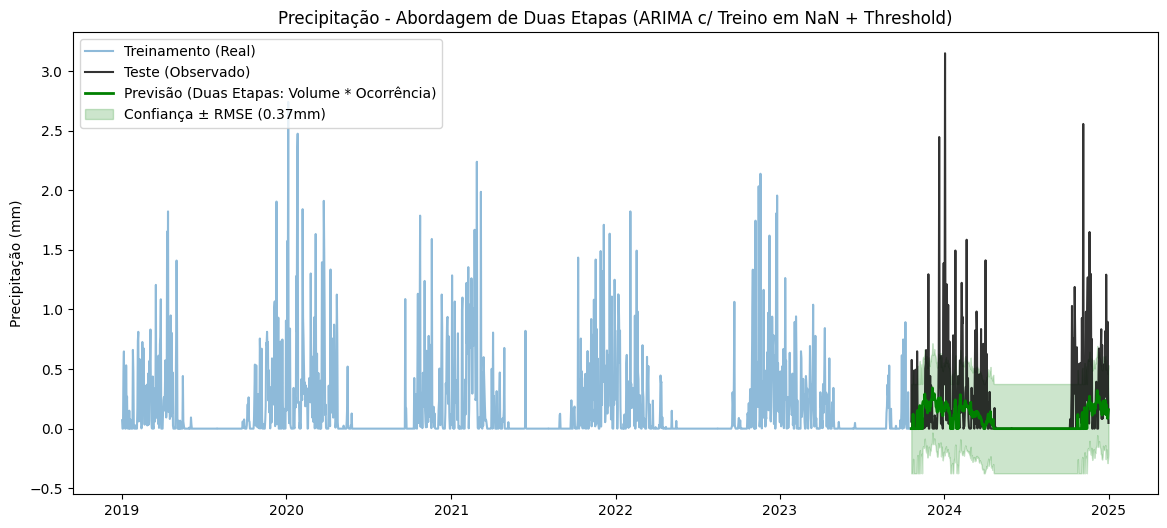

In [11]:
# ==============================================================================
# ABORDAGEM DE DUAS ETAPAS (HURDLE MODEL COM ARIMA)
# Etapa 1 (Volume): Treino focando apenas no volume de chuva (substituindo <=0 por NaN)
# Etapa 2 (Ocorrência): Classificador binário via Threshold da Umidade
# Saída Final: Volume Previsto * Previsão de Ocorrência (0 ou 1)
# ==============================================================================

# Criação do DataFrame de treinamento substituindo valores sem chuva por NaN para focar no volume
df_training_chuvoso = df_training.copy()
df_training_chuvoso.loc[df_training_chuvoso['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 0, 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] = np.nan

# ================= 1. PREPARAÇÃO DAS EXÓGENAS DO TREINO E TESTE =================
n_train = len(df_training)
t_train = np.arange(n_train)
seasonality = 365
num_fourier_terms = 4

exog_vars = [
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)",
    "UMIDADE RELATIVA DO AR, HORARIA (%)"
]

fourier_train = create_fourier_terms(t_train, seasonality, num_fourier_terms)
X_train_exog_df = df_training[exog_vars].copy()
X_train_final = np.hstack([X_train_exog_df.values, fourier_train])

# Perfil para substituir falhas no teste (como as feitas anteriormente)
prof = df_training.copy()
prof["__mm__"] = prof.index.month
prof["__dd__"] = prof.index.day
profile_mmdd = prof.groupby(["__mm__", "__dd__"])[exog_vars].mean()  

test_mm = pd.Index(df_test.index.month, name="__mm__")
test_dd = pd.Index(df_test.index.day, name="__dd__")
test_mmdd = pd.MultiIndex.from_arrays([test_mm, test_dd], names=["__mm__", "__dd__"])

X_test_exog_df = profile_mmdd.reindex(test_mmdd).copy()

for col in exog_vars:
    if X_test_exog_df[col].isna().any():
        X_test_exog_df[col] = X_test_exog_df[col].fillna(X_test_exog_df[col].mean())

# Utiliza a previsão da umidade para criar o cenário do teste do ARIMA
X_test_exog_df['UMIDADE RELATIVA DO AR, HORARIA (%)'] = forecast.values

fourier_test = create_fourier_terms(np.arange(n_train, n_train + len(df_test)), seasonality, num_fourier_terms)
X_test_final = np.hstack([X_test_exog_df.values, fourier_test])

# ================= 2. ETAPA DO VOLUME (ARIMA SOMENTE COM DIAS CHUVOSOS) =================
print("--- Treinando o ARIMA apenas para volume dos dias de chuva ---")

model_chuva = ARIMA(
    df_training_chuvoso['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], 
    exog=X_train_final,
    order=(3,0,1),
    trend='ct'
)
model_chuva_fit = model_chuva.fit()

# Previsão do volume 
previsao_volume_chuva = model_chuva_fit.forecast(steps=len(df_test), exog=X_test_final).values

# Garante que não haja precipitações negativas no volume
previsao_volume_chuva = np.maximum(previsao_volume_chuva, 0)

# ================= 3. ETAPA DA OCORRÊNCIA (CLASSIFICAÇÃO BINÁRIA VIA THRESHOLD) =================
print(f"Aplicando Optimized Threshold: {threshold_otimizado:.2f}% de Umidade para prever ocorrência...")
previsao_chove_teste = (forecast.values > threshold_otimizado).astype(int)

# ================= 4. MISTURA = SAÍDA CONJUNTA (VOLUME * OCORRÊNCIA) =================
forecast_two_stage = previsao_volume_chuva * previsao_chove_teste
forecast_two_stage_series = pd.Series(forecast_two_stage, index=df_test.index, name='forecast_two_stage')

# ================= 5. AVALIAÇÃO DO MODELO =================
mse_2s = mean_squared_error(df_test['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], forecast_two_stage_series)
rmse_2s = mse_2s ** 0.5
smape_2s = smape(df_test['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], forecast_two_stage_series)

print("\n--- MÉTRICAS DE ERRO (ARIMAX EM DUAS ETAPAS) ---")
print(f'MSE:   {mse_2s:.4f}')
print(f'RMSE:  {rmse_2s:.4f}')
print(f'sMAPE: {smape_2s:.4f}')

lower_bound_2s = forecast_two_stage_series - rmse_2s
upper_bound_2s = forecast_two_stage_series + rmse_2s
within_range_2s = ((df_test['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= lower_bound_2s) & (df_test['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= upper_bound_2s)).mean() * 100
print(f"Pontos dentro do intervalo (Previsto ± RMSE): {within_range_2s:.2f}%")

# ================= 6. PLOT DOS RESULTADOS =================
plt.figure(figsize=(14, 6))
plt.plot(df_training.index, df_training['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], label='Training (Observed)', alpha=0.5)
plt.plot(df_test.index, df_test['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], label='Test (Observed)', alpha=0.8, color='black')
plt.plot(df_test.index, forecast_two_stage_series, label='Forecast (Two-Stage: Volume * Occurrence)', color='green', linewidth=2)

plt.fill_between(df_test.index, lower_bound_2s, upper_bound_2s, alpha=.2, color='green', label=f'Confidence +- RMSE ({rmse_2s:.2f}mm)')

plt.ylabel('Precipitation (mm)')
plt.title(f'Precipitation - Two-Stage Approach (ARIMA with NaN Training + Threshold)')
plt.legend(loc='upper left')
plt.show()

--- Treinando o ARIMA no espaço logarítmico (Volume) ---


/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



--- MÉTRICAS DE ERRO (ARIMAX LOGARÍTMICO EM DUAS ETAPAS) ---
MSE:   0.1407
RMSE:  0.3751
sMAPE: 130.0497
Pontos dentro do intervalo (Previsto ± RMSE): 86.10%


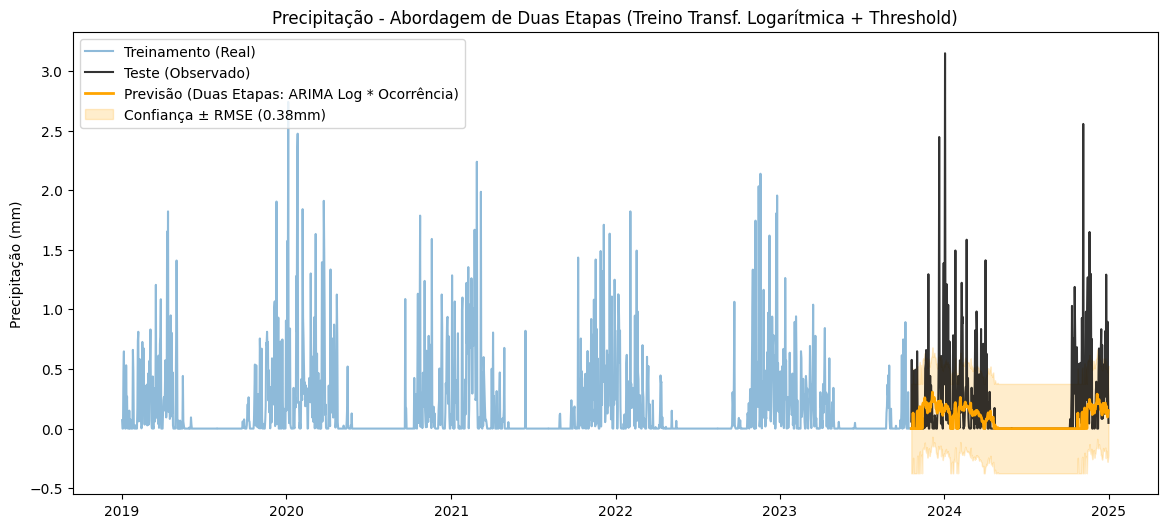

In [12]:
# ==============================================================================
# ABORDAGEM DE DUAS ETAPAS COM TRANSFORMAÇÃO LOGARÍTMICA (ARIMA)
# Etapa 1 (Volume): Treino focando no volume logarítmico log(x+1) dos dias chuvosos
# Etapa 2 (Ocorrência): Classificador binário via Threshold da Umidade
# ==============================================================================

# Criação do DataFrame de treinamento para volume (ignorando dias sem chuva -> NaN)
df_training_log = df_training.copy()

# Aplicando a transformação logarítmica: log(x + 1)
df_training_log['PRECIPITAÇÃO LOG'] = np.log1p(df_training_log['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'])

# Substituindo o que era <= 0 por NaN para focar nos picos logarítmicos
df_training_log.loc[df_training['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 0, 'PRECIPITAÇÃO LOG'] = np.nan

# Os dados exógenos já foram construídos nas células anteriores: X_train_final e X_test_final
# Reutilizaremos X_train_final e X_test_final para alimentar o modelo.

print("--- Treinando o ARIMA no espaço logarítmico (Volume) ---")
model_log = ARIMA(
    df_training_log['PRECIPITAÇÃO LOG'], 
    exog=X_train_final,
    order=(3,0,1),
    trend='ct'
)
model_log_fit = model_log.fit()

# Previsão do volume no espaço log
previsao_volume_log = model_log_fit.forecast(steps=len(df_test), exog=X_test_final).values

# Revertendo a transformação logarítmica: exp(x) - 1
previsao_volume_chuva_exp = np.expm1(previsao_volume_log)
# Garante que não haja precipitações negativas no volume revertido
previsao_volume_chuva_exp = np.maximum(previsao_volume_chuva_exp, 0)

# ================= ETAPA DA OCORRÊNCIA (REUTILIZANDO THRESHOLD MÁX F1) =================
# Classificação binária 1 ou 0
previsao_chove_teste = (forecast.values > threshold_otimizado).astype(int)

# ================= MISTURA = SAÍDA CONJUNTA (VOLUME EXP * OCORRÊNCIA) =================
forecast_log_exog = previsao_volume_chuva_exp * previsao_chove_teste
forecast_log_exog_series = pd.Series(forecast_log_exog, index=df_test.index, name='forecast_log_exog')

# ================= AVALIAÇÃO DO MODELO =================
mse_log = mean_squared_error(df_test['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], forecast_log_exog_series)
rmse_log = mse_log ** 0.5
smape_log = smape(df_test['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], forecast_log_exog_series)

print("\n--- MÉTRICAS DE ERRO (ARIMAX LOGARÍTMICO EM DUAS ETAPAS) ---")
print(f'MSE:   {mse_log:.4f}')
print(f'RMSE:  {rmse_log:.4f}')
print(f'sMAPE: {smape_log:.4f}')

lower_bound_log = forecast_log_exog_series - rmse_log
upper_bound_log = forecast_log_exog_series + rmse_log
within_range_log = ((df_test['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= lower_bound_log) & (df_test['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= upper_bound_log)).mean() * 100
print(f"Pontos dentro do intervalo (Previsto ± RMSE): {within_range_log:.2f}%")

# ================= PLOT DOS RESULTADOS =================
plt.figure(figsize=(14, 6))
plt.plot(df_training.index, df_training['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], label='Training (Observed)', alpha=0.5)
plt.plot(df_test.index, df_test['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], label='Test (Observed)', alpha=0.8, color='black')
plt.plot(df_test.index, forecast_log_exog_series, label='Forecast (Two-Stage: ARIMA Log * Occurrence)', color='orange', linewidth=2)

plt.fill_between(df_test.index, lower_bound_log, upper_bound_log, alpha=.2, color='orange', label=f'Confidence +- RMSE ({rmse_log:.2f}mm)')

plt.ylabel('Precipitation (mm)')
plt.title(f'Precipitation - Two-Stage Approach (Log-Transformed Training + Threshold)')
plt.legend(loc='upper left')
plt.show()

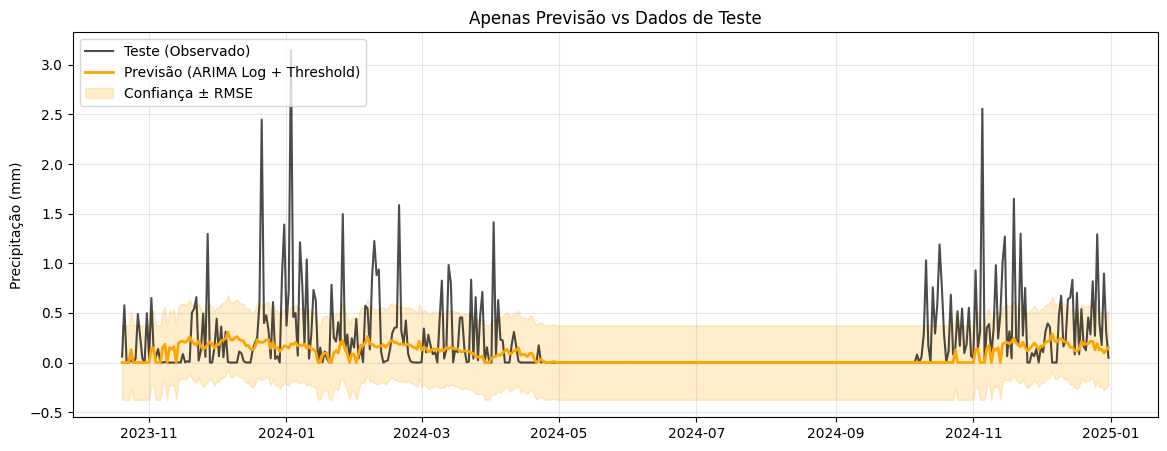

In [ ]:
# ==============================================================================
# VISUALIZAÇÃO ISOLADA: FOCO NOS RESULTADOS
# Gráfico 1: Apenas Teste (Observado) vs Previsão 
# Gráfico 2: Apenas Treino (Histórico) e Previsão (Continuidade)
# ==============================================================================

# Gráfico 1: Foco no Teste (Verificando o aderência ao real)
plt.figure(figsize=(14, 5))
plt.plot(df_test.index, df_test['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'], label='Test (Observed)', color='black', alpha=0.7)
plt.plot(df_test.index, forecast_log_exog_series, label='Forecast (ARIMA Log + Threshold)', color='orange', linewidth=2)
plt.fill_between(df_test.index, lower_bound_log, upper_bound_log, alpha=.2, color='orange', label=f'Confidence +- RMSE')
plt.ylabel('Precipitation (mm)')
plt.title('Forecast Only vs Test Data')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()



P95 no Treino: 0.89 mm
K=2, Log=False -> RMSE Geral: 0.29 | RMSE Picos: 1.07
K=2, Log=True -> RMSE Geral: 0.30 | RMSE Picos: 1.12
K=4, Log=False -> RMSE Geral: 0.29 | RMSE Picos: 1.07
K=4, Log=True -> RMSE Geral: 0.30 | RMSE Picos: 1.12

--- Melhor Modelo ---
K=4, Log=False
MAE Geral: 0.152
RMSE Geral: 0.294
MAE Picos: 0.927
RMSE Picos: 1.067
Viés Picos: -0.927
Subestimados: 23
% Subestimados: 1.000


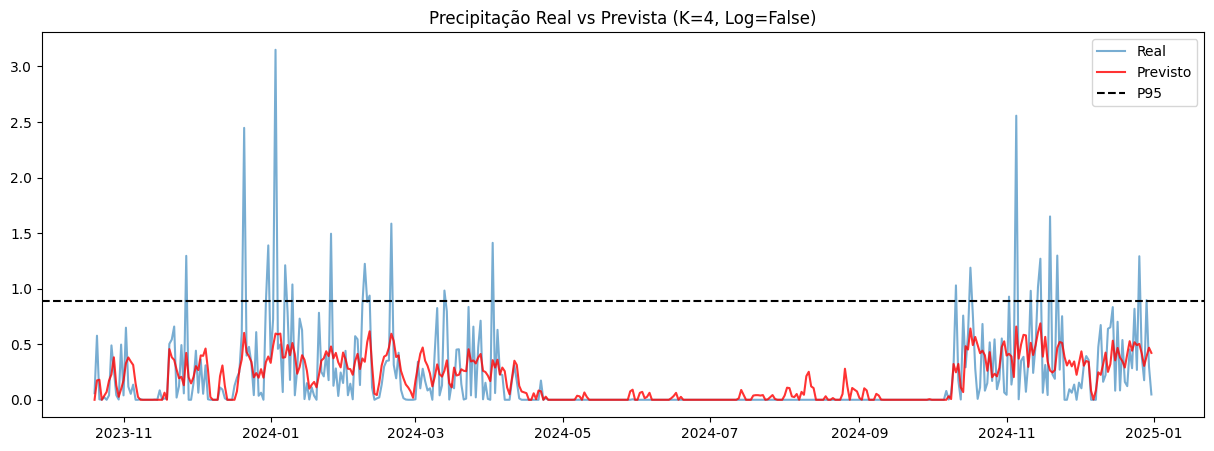


Amostra da Tabela Final:
        Data  Real (mm)  Previsto (mm)      Erro  Pico Real
0 2023-10-20   0.059341       0.000000 -0.059341      False
1 2023-10-21   0.576596       0.174519 -0.402077      False
2 2023-10-22   0.004211       0.180278  0.176067      False
3 2023-10-23   0.000000       0.000000  0.000000      False
4 2023-10-24   0.022472       0.035365  0.012893      False


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# 1. Funções Auxiliares
def create_fourier_terms(t, period, num_terms):
    terms = []
    for i in range(1, num_terms + 1):
        terms.append(np.sin(2 * np.pi * i * t / period))
        terms.append(np.cos(2 * np.pi * i * t / period))
    return np.column_stack(terms)

def avaliar_previsao(y_true, y_pred, p95_treino):
    mae_geral = mean_absolute_error(y_true, y_pred)
    rmse_geral = mean_squared_error(y_true, y_pred) ** 0.5
    
    idx_picos = y_true >= p95_treino
    y_true_picos = y_true[idx_picos]
    y_pred_picos = y_pred[idx_picos]
    
    if len(y_true_picos) > 0:
        mae_picos = mean_absolute_error(y_true_picos, y_pred_picos)
        rmse_picos = mean_squared_error(y_true_picos, y_pred_picos) ** 0.5
        vies_picos = np.mean(y_pred_picos - y_true_picos)
        subestimados = np.sum(y_pred_picos < y_true_picos)
        pct_subestimados = subestimados / len(y_true_picos)
    else:
        mae_picos = rmse_picos = vies_picos = subestimados = pct_subestimados = np.nan
        
    return {
        'MAE Geral': mae_geral,
        'RMSE Geral': rmse_geral,
        'MAE Picos': mae_picos,
        'RMSE Picos': rmse_picos,
        'Viés Picos': vies_picos,
        'Subestimados': subestimados,
        '% Subestimados': pct_subestimados
    }

# 2. Pipeline Principal
def treinar_e_avaliar_arimax(df_treino, df_teste, param_alvo, exog_cols, K, p, d, q, usar_log=False):
    t_treino = np.arange(len(df_treino))
    t_teste = np.arange(len(df_treino), len(df_treino) + len(df_teste))
    
    fourier_treino = create_fourier_terms(t_treino, 365, K)
    fourier_teste = create_fourier_terms(t_teste, 365, K)
    
    exog_treino = np.hstack([df_treino[exog_cols].values, fourier_treino])
    exog_teste = np.hstack([df_teste[exog_cols].values, fourier_teste])
    
    y_treino = df_treino[param_alvo].values
    if usar_log:
        y_treino = np.log1p(y_treino)
        
    modelo = ARIMA(y_treino, exog=exog_treino, order=(p,d,q))
    resultado = modelo.fit()
    
    pred = resultado.forecast(steps=len(df_teste), exog=exog_teste)
    
    if usar_log:
        pred = np.expm1(pred)
        
    pred = np.maximum(pred, 0) # precipitação não pode ser negativa
    return pred

# 3. Execução
param_alvo = 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'
exog_cols = ["TEMPERATURA DO PONTO DE ORVALHO (°C)", "UMIDADE RELATIVA DO AR, HORARIA (%)"]

# Preenchendo NAs nas exógenas se houver
df_training[exog_cols] = df_training[exog_cols].fillna(method='ffill')
df_test[exog_cols] = df_test[exog_cols].fillna(method='ffill')

p95_treino = np.percentile(df_training[param_alvo], 95)
print(f"P95 no Treino: {p95_treino:.2f} mm")

Ks_para_testar = [2, 4]
log_opts = [False, True]
melhor_resultado = None
melhor_k = 0

resultados = []

for K in Ks_para_testar:
    for usar_log in log_opts:
        # Faremos (2,0,1) por simplicidade de tempo
        pred = treinar_e_avaliar_arimax(df_training, df_test, param_alvo, exog_cols, K, 2, 0, 1, usar_log)
        metricas = avaliar_previsao(df_test[param_alvo].values, pred, p95_treino)
        
        resultados.append({
            'K': K,
            'Log': usar_log,
            'Pred': pred,
            **metricas
        })
        
        print(f"K={K}, Log={usar_log} -> RMSE Geral: {metricas['RMSE Geral']:.2f} | RMSE Picos: {metricas['RMSE Picos']:.2f}")

# Encontra melhor modelo (minimizar RMSE Picos ou combinar)
melhor_modelo = min(resultados, key=lambda x: x['RMSE Picos'])

print("\n--- Melhor Modelo ---")
print(f"K={melhor_modelo['K']}, Log={melhor_modelo['Log']}")
for k, v in melhor_modelo.items():
    if k not in ['K', 'Log', 'Pred']:
        print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}")

df_resultados = pd.DataFrame({
    'Data': df_test.index,
    'Real (mm)': df_test[param_alvo].values,
    'Previsto (mm)': melhor_modelo['Pred']
})
df_resultados['Erro'] = df_resultados['Previsto (mm)'] - df_resultados['Real (mm)']
df_resultados['Pico Real'] = df_resultados['Real (mm)'] >= p95_treino

plt.figure(figsize=(15,5))
plt.plot(df_resultados['Data'], df_resultados['Real (mm)'], label='Observed', alpha=0.6)
plt.plot(df_resultados['Data'], df_resultados['Previsto (mm)'], label='Predicted', alpha=0.8, color='red')
plt.axhline(p95_treino, color='black', linestyle='--', label='P95')
plt.title(f"Observed vs Predicted Precipitation (K={melhor_modelo['K']}, Log={melhor_modelo['Log']})")
plt.legend()
plt.show()

print("\nAmostra da Tabela Final:")
print(df_resultados.head())


Executando modelos com Estratégia Melhorada para Picos...


K=2, Log=False | Geral: RMSE=0.45, Picos: RMSE=0.91, Viés=-0.74
K=2, Log=True | Geral: RMSE=0.46, Picos: RMSE=0.95, Viés=-0.79
K=4, Log=False | Geral: RMSE=0.45, Picos: RMSE=0.91, Viés=-0.75
K=4, Log=True | Geral: RMSE=0.46, Picos: RMSE=0.95, Viés=-0.79
K=6, Log=False | Geral: RMSE=0.45, Picos: RMSE=0.92, Viés=-0.75
K=6, Log=True | Geral: RMSE=0.46, Picos: RMSE=0.96, Viés=-0.80

--- Melhor Modelo (Foco em Picos) ---
K=4, Log=False
K: 4
Log: False
BiasAdicionado: 0.832
MAE Geral: 0.265
RMSE Geral: 0.450
MAE Picos: 0.783
RMSE Picos: 0.909
Viés Picos: -0.746
Subestimados: 22
% Subestimados: 0.957


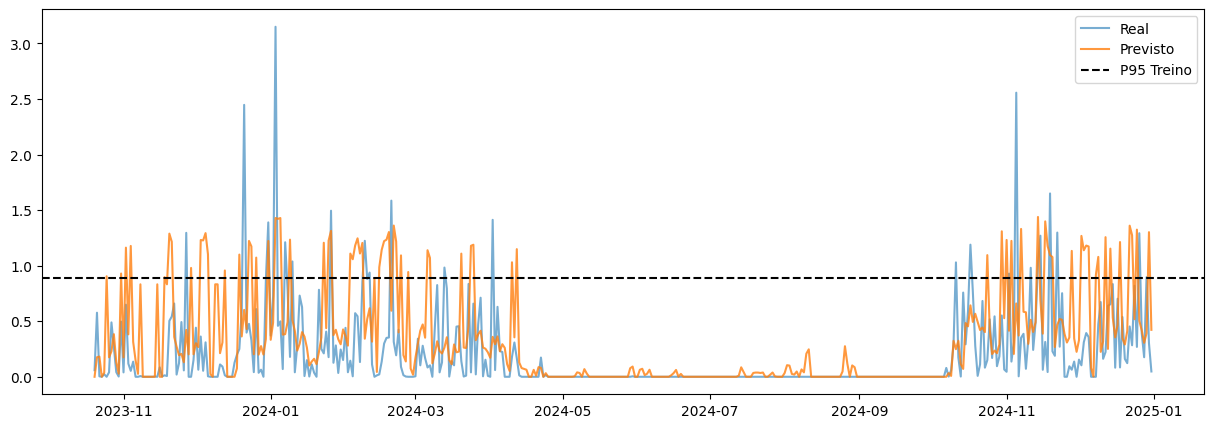

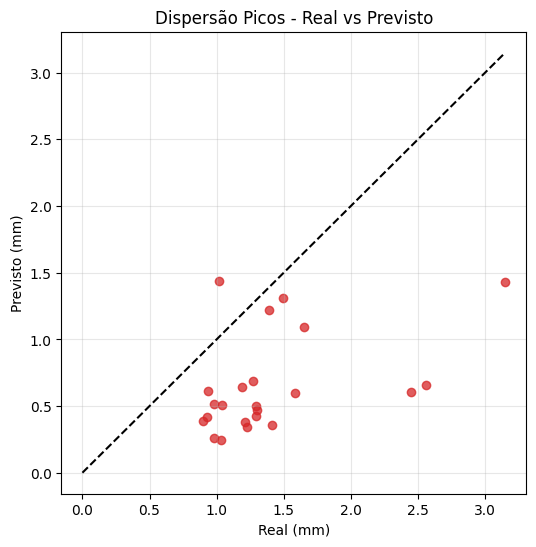

In [ ]:
# ==============================================================================
# PIPELINE MELHORA PICOS DE PRECIPITAÇÃO
# Integrado com a abordagem anterior (ARIMA, Fourier, Exógenas)
# Estratégia de Picos mantida: 
# 1. Ajuste de Bias Aditivo
# 2. Threshold de Umidade (Zero Chuva)
# 3. Otimização avaliando Erro nos Picos
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# 1. Funções de Melhoria para Picos 
def get_humidity_threshold(df_treino, param_alvo, col_umidade):
    # Determina o nível mínimo de umidade em que ocorreu chuva no treino
    df_chuva = df_treino[df_treino[param_alvo] > 0]
    return df_chuva[col_umidade].min() if len(df_chuva) > 0 else np.nan

def apply_peak_bias_adjustment(y_train, pred_train, pred_teste, p95_treino, index_treino, index_teste):
    # Calcula a subestimacão média ocorrida APENAS nos picos durante o treino
    y_train_s = pd.Series(y_train, index=index_treino)
    p_train_s = pd.Series(pred_train, index=index_treino)
    
    peak_mask = y_train_s >= p95_treino
    if peak_mask.sum() > 0:
        under = (y_train_s[peak_mask] - p_train_s[peak_mask]).clip(lower=0)
        additive_bias = under.mean()
    else:
        additive_bias = 0.0

    # Aplica esse bias nos dias do ano no teste onde é tipicamente chuvoso (> q85 histórico)
    climatology = y_train_s.groupby(y_train_s.index.dayofyear).mean()
    if len(climatology) > 0:
        lim = climatology.quantile(0.85)
        high_risk_doys = set(climatology[climatology >= lim].index)
    else:
        high_risk_doys = set()

    pred_s = pd.Series(pred_teste, index=index_teste)
    if additive_bias > 0 and len(high_risk_doys) > 0:
        risk_mask = pred_s.index.dayofyear.isin(high_risk_doys)
        pred_s.loc[risk_mask] += additive_bias
        
    return np.maximum(pred_s.values, 0), additive_bias

def treinar_e_avaliar_melhorado(df_treino, df_teste, param_alvo, exog_cols, col_umidade, K, p, d, q, usar_log=False):
    t_treino = np.arange(len(df_treino))
    t_teste = np.arange(len(df_treino), len(df_treino) + len(df_teste))
    
    fourier_treino = create_fourier_terms(t_treino, 365.25, K)
    fourier_teste = create_fourier_terms(t_teste, 365.25, K)
    
    exog_treino = np.hstack([df_treino[exog_cols].values, fourier_treino])
    exog_teste = np.hstack([df_teste[exog_cols].values, fourier_teste])
    
    y_treino = df_treino[param_alvo].values
    if usar_log:
        y_treino = np.log1p(y_treino)
        
    modelo = ARIMA(y_treino, exog=exog_treino, order=(p,d,q))
    resultado = modelo.fit()
    
    pred_treino = resultado.fittedvalues
    pred_teste = resultado.forecast(steps=len(df_teste), exog=exog_teste)
    
    if usar_log:
        pred_treino = np.expm1(pred_treino)
        pred_teste = np.expm1(pred_teste)
        
    pred_treino = np.maximum(pred_treino, 0)
    pred_teste = np.maximum(pred_teste, 0)
    
    # Aplicar as estratégias de picos
    p95_treino = np.percentile(df_treino[param_alvo], 95)
    
    pred_teste_adj, bias = apply_peak_bias_adjustment(
        df_treino[param_alvo].values, pred_treino, pred_teste, 
        p95_treino, df_treino.index, df_teste.index
    )
    
    # Threshold de umidade (zerar previsão onde sabidamente não chove)
    if col_umidade in df_teste.columns:
        thresh_nunca_chove = get_humidity_threshold(df_treino, param_alvo, col_umidade)
        if not np.isnan(thresh_nunca_chove):
            umid_teste = df_teste[col_umidade].values
            pred_teste_adj[umid_teste <= thresh_nunca_chove] = 0.0
            
    return pred_teste_adj, bias

# 2. Execução das configurações usando a nova estratégia
col_umidade = "UMIDADE RELATIVA DO AR, HORARIA (%)"

Ks_para_testar = [2, 4, 6]
log_opts = [False, True]
resultados_melhorados = []

print("Executando modelos com Estratégia Melhorada para Picos...")
for K in Ks_para_testar:
    for usar_log in log_opts:
        try:
            pred_adj, bias_adds = treinar_e_avaliar_melhorado(
                df_training, df_test, param_alvo, exog_cols, col_umidade, K, 2, 0, 1, usar_log
            )
            metricas = avaliar_previsao(df_test[param_alvo].values, pred_adj, p95_treino)
            
            resultados_melhorados.append({
                'K': K,
                'Log': usar_log,
                'Pred': pred_adj,
                'BiasAdicionado': bias_adds,
                **metricas
            })
            
            print(f"K={K}, Log={usar_log} | Geral: RMSE={metricas['RMSE Geral']:.2f}, Picos: RMSE={metricas['RMSE Picos']:.2f}, Viés={metricas['Viés Picos']:.2f}")
        except Exception as e:
            print(f"ERRO K={K}, Log={usar_log}: {e}")

# Seleciona o melhor pelo Score ponderado da Estratégia de Picos
def score_picos(r):
    rmse_g = r['RMSE Geral']
    mae_g = r['MAE Geral']
    rmse_p = r['RMSE Picos']
    mae_p = r['MAE Picos']
    vies_p = r.get('Viés Picos', 0)
    
    # Custo ponderado similar à implementação original
    return 1.0*rmse_g + 0.5*mae_g + 2.5*rmse_p + 2.0*mae_p + 3.0*max(-vies_p, 0.0)

melhor_modelo_pic = min(resultados_melhorados, key=score_picos)

print("\n--- Melhor Modelo (Foco em Picos) ---")
print(f"K={melhor_modelo_pic['K']}, Log={melhor_modelo_pic['Log']}")
for k, v in melhor_modelo_pic.items():
    if k not in ['Pred']:
        print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}")

df_resultados_pic = pd.DataFrame({
    'Data': df_test.index,
    'Real (mm)': df_test[param_alvo].values,
    'Previsto (mm)': melhor_modelo_pic['Pred']
})
df_resultados_pic['Erro'] = df_resultados_pic['Previsto (mm)'] - df_resultados_pic['Real (mm)']
df_resultados_pic['Pico Real'] = df_resultados_pic['Real (mm)'] >= p95_treino

plt.figure(figsize=(15,5))
plt.plot(df_resultados_pic['Data'], df_resultados_pic['Real (mm)'], label='Observed', alpha=0.6)
plt.plot(df_resultados_pic['Data'], df_resultados_pic['Previsto (mm)'], label='Predicted', alpha=0.8, color='tab:orange')
plt.axhline(p95_treino, color='black', linestyle='--', label='P95 Training')
plt.legend()
plt.show()

# Dispersão Picos
plt.figure(figsize=(6,6))
peaks_pic = df_resultados_pic[df_resultados_pic['Pico Real']]
if len(peaks_pic) > 0:
    plt.scatter(peaks_pic['Real (mm)'], peaks_pic['Previsto (mm)'], color='tab:red', alpha=0.75)
    limp = max(peaks_pic['Real (mm)'].max(), peaks_pic['Previsto (mm)'].max())
    plt.plot([0, limp], [0, limp], 'k--')
    plt.title('Peak Scatter - Observed vs Predicted')
    plt.xlabel('Real (mm)')
    plt.ylabel('Predicted (mm)')
    plt.grid(alpha=0.3)
plt.show()


MÉTRICAS FINAIS:
RMSE: 0.450 mm
sMAPE: 86.87%
--------------------------------------------------
Total de pontos avaliados: 439
Pontos reais fora da faixa dinâmica (+/- RMSE): 96 (21.87%)


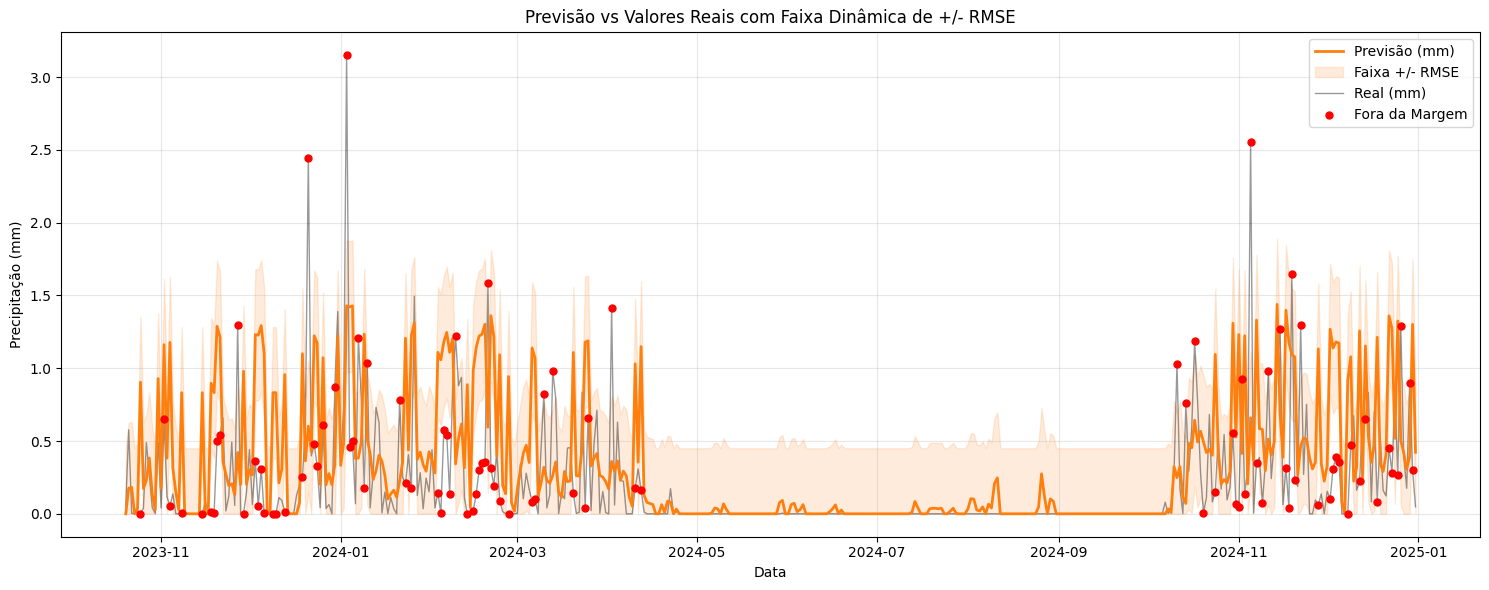

In [20]:
# ==============================================================================
# AVALIAÇÃO: PONTOS FORA DA FAIXA DE RMSE E CÁLCULO DO sMAPE
# Analisa quais pontos reais estão além da faixa dinâmica de (Previsão +/- RMSE)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Utilizamos o dataframe de resultados do melhor modelo salvo na etapa anterior
df_plot = df_resultados_pic.copy()

# Calcula o RMSE geral no teste
rmse_final = np.sqrt((df_plot['Erro'] ** 2).mean())

# --- CÁLCULO DO sMAPE ---
# Evita divisão por zero: quando Real e Previsto são ambos zero, adiciona um epsilon ou substitui
# Formula: 100/n * sum( |F - A| / ((|A| + |F|)/2) )
numerador = np.abs(df_plot['Previsto (mm)'] - df_plot['Real (mm)'])
denominador = (np.abs(df_plot['Real (mm)']) + np.abs(df_plot['Previsto (mm)'])) / 2.0

# Onde ambos são exatamente 0, o sMAPE é naturalmente 0 (pois não há erro e não há variação)
sMAPE_series = np.where(denominador == 0, 0, numerador / denominador)
smape_final = np.mean(sMAPE_series) * 100

# Define o limite Superior e Inferior acompanhando a Previsão
df_plot['Limite_Superior'] = df_plot['Previsto (mm)'] + rmse_final
# Tratamos o limite inferior limitando a zero, afinal não existe precipitação negativa
df_plot['Limite_Inferior'] = np.maximum(df_plot['Previsto (mm)'] - rmse_final, 0)

# Checa se o valor Real cai FORA dessa nova margem móvel
df_plot['Fora_Faixa_RMSE'] = (df_plot['Real (mm)'] > df_plot['Limite_Superior']) | (df_plot['Real (mm)'] < df_plot['Limite_Inferior'])

total_pontos = len(df_plot)
pontos_fora = df_plot['Fora_Faixa_RMSE'].sum()
percentual_fora = (pontos_fora / total_pontos) * 100

print(f"MÉTRICAS FINAIS:")
print(f"RMSE: {rmse_final:.3f} mm")
print(f"sMAPE: {smape_final:.2f}%")
print("-" * 50)
print(f"Total de pontos avaliados: {total_pontos}")
print(f"Pontos reais fora da faixa dinâmica (+/- RMSE): {pontos_fora} ({percentual_fora:.2f}%)")

# ----- Visualização -----
plt.figure(figsize=(15, 6))

# 1. Plota a Previsão e cria a "sombra" dos limites ao redor dela
plt.plot(df_plot['Data'], df_plot['Previsto (mm)'], label='Forecast (mm)', color='tab:orange', linewidth=2, zorder=3)
plt.fill_between(df_plot['Data'], df_plot['Limite_Inferior'], df_plot['Limite_Superior'], 
                 color='tab:orange', alpha=0.15, label='Faixa +/- RMSE', zorder=1)

# 2. Plota as observações Reais (linhas normais ou dispersão mais fraca para os que acertou)
plt.plot(df_plot['Data'], df_plot['Real (mm)'], label='Observed (mm)', color='black', alpha=0.4, linewidth=1, zorder=2)

# 3. Destaca os que fugiram da faixa acompanhada
fora_df = df_plot[df_plot['Fora_Faixa_RMSE']]
if not fora_df.empty:
    plt.scatter(fora_df['Data'], fora_df['Real (mm)'], color='red', s=25, label='Outside Margin', zorder=4)

plt.title("Forecast vs Observed Values with Dynamic +/- RMSE Band")
plt.xlabel("Data")
plt.ylabel("Precipitation (mm)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()